## 🔄 Обновления (latest)

**Добавлена функциональность сохранения/загрузки:**

1. **Разбиение датасета** (`dataset_split.pkl`)
   - Сохраняет train/val/test split для воспроизводимости
   - Избегает повторной загрузки и обработки JSON каждый раз
   - Функции: `save_dataset_split()`, `load_dataset_split()`

2. **Unseen датасет** (`unseen_dataset.pkl`)
   - Сохраняет сгенерированные unseen классы с эмбеддингами
   - Избегает дорогих вызовов Ollama API при повторных запусках
   - Функции: `save_unseen_dataset()`, `load_unseen_dataset()`

3. **Улучшения стабильности:**
   - Исправлена обработка загрузки предобученной модели
   - Добавлены проверки на наличие сохраненных данных
   - Безопасная работа с пустой историей обучения

**Использование:**
- При первом запуске: датасеты генерируются и сохраняются
- При последующих запусках: данные загружаются из .pkl файлов
- Для пересоздания: удалите соответствующий .pkl файл

# 🔥 Triplet Loss для Column Embeddings

Эксперимент с обучением модели через Triplet Loss для улучшения разделимости эмбеддингов столбцов.

**Используемые технологии:**
- PyTorch для модели проекции
- **pytorch-metric-learning** для продвинутого Triplet Loss и hard mining
- t-SNE для визуализации

**План:**
1. Загрузка датасета и разделение на train/val/test
2. Визуализация исходных эмбеддингов (t-SNE)
3. Создание простой модели проекции (4096 → 1024)
4. Обучение с Triplet Loss + MultiSimilarityMiner (hard triplets)
5. Визуализация новых эмбеддингов (t-SNE)
6. Сравнение метрик до/после:
   - Separability (intra-class vs inter-class similarity)
   - Precision@1, R-Precision, MAP@R
   - FAR/FRR кривые и EER (Equal Error Rate)
   - ROC кривые (TAR vs FAR)

## 1️⃣ Импорты и настройки

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from datetime import datetime, timedelta
import random
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# pytorch-metric-learning
from pytorch_metric_learning import losses, miners, distances, reducers, testers
from pytorch_metric_learning.utils.accuracy_calculator import AccuracyCalculator

# Настройки
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Константы
DATASET_DIR = Path(r"C:\Work\TableUnifier\datasets\dataset_1000t_qwen3_8b_qwen3-embedding_8b")
QWEN_DIM = 4096  # Размерность qwen3-embedding
OUTPUT_DIM = 4096  # Новая размерность после проекции
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001
MARGIN = 0.2  # Margin для Triplet Loss

# Пути для сохранения промежуточных результатов
EXPERIMENT_DIR = Path(".")
MODEL_PATH = EXPERIMENT_DIR / "triplet_loss_model.pth"
UNSEEN_DATA_PATH = EXPERIMENT_DIR / "unseen_dataset.pkl"
CONFIG_PATH = EXPERIMENT_DIR / "experiment_config.json"
DATASET_SPLIT_PATH = EXPERIMENT_DIR / "dataset_split.pkl"  # НОВОЕ: путь для сохранения разбиения

print("✅ Импорты загружены (включая pytorch-metric-learning)")
print(f"📁 Рабочая директория: {EXPERIMENT_DIR.absolute()}")
print(f"💾 Пути к файлам:")
print(f"   Модель: {MODEL_PATH}")
print(f"   Unseen датасет: {UNSEEN_DATA_PATH}")
print(f"   Конфигурация: {CONFIG_PATH}")
print(f"   Разбиение датасета: {DATASET_SPLIT_PATH}")

Используемое устройство: cpu
✅ Импорты загружены (включая pytorch-metric-learning)
📁 Рабочая директория: c:\Work\TableUnifier\pipelines\triplet_loss
💾 Пути к файлам:
   Модель: triplet_loss_model.pth
   Unseen датасет: unseen_dataset.pkl
   Конфигурация: experiment_config.json
   Разбиение датасета: dataset_split.pkl


### 💾 Вспомогательные функции для сохранения/загрузки

Сохраняем промежуточные результаты для ускорения экспериментов

In [7]:
def save_dataset_split(X_train, y_train, X_val, y_val, X_test, y_test, 
                      embeddings, labels, label_to_idx, dataset, 
                      filepath=DATASET_SPLIT_PATH):
    """Сохранение разбиения датасета для переиспользования"""
    data_to_save = {
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'X_test': X_test,
        'y_test': y_test,
        'embeddings': embeddings,
        'labels': labels,
        'label_to_idx': label_to_idx,
        'dataset': dataset,
        'timestamp': datetime.now().isoformat(),
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'num_classes': len(label_to_idx)
    }
    
    with open(filepath, 'wb') as f:
        pickle.dump(data_to_save, f)
    
    print(f"💾 Разбиение датасета сохранено: {filepath}")
    print(f"   Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
    print(f"   Классов: {len(label_to_idx)}")

def load_dataset_split(filepath=DATASET_SPLIT_PATH):
    """Загрузка сохраненного разбиения датасета"""
    if not filepath.exists():
        return None
    
    try:
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        
        print(f"✅ Разбиение датасета загружено: {filepath}")
        print(f"   Дата создания: {data.get('timestamp', 'N/A')}")
        print(f"   Train: {data.get('train_size', 'N/A')}, Val: {data.get('val_size', 'N/A')}, Test: {data.get('test_size', 'N/A')}")
        print(f"   Классов: {data.get('num_classes', 'N/A')}")
        
        return (data['X_train'], data['y_train'], 
                data['X_val'], data['y_val'], 
                data['X_test'], data['y_test'],
                data['embeddings'], data['labels'], 
                data['label_to_idx'], data['dataset'])
    except Exception as e:
        print(f"⚠️  Ошибка при загрузке разбиения: {e}")
        return None

def save_unseen_dataset(unseen_data, X_unseen, y_unseen, filepath=UNSEEN_DATA_PATH):
    """Сохранение unseen датасета для переиспользования"""
    data_to_save = {
        'unseen_data': unseen_data,  # Список словарей с информацией о классах
        'X_unseen': X_unseen,  # Эмбеддинги
        'y_unseen': y_unseen,  # Метки
        'timestamp': datetime.now().isoformat(),
        'num_classes': len(unseen_data),
        'num_samples': len(X_unseen)
    }
    
    with open(filepath, 'wb') as f:
        pickle.dump(data_to_save, f)
    
    print(f"💾 Unseen датасет сохранен: {filepath}")
    print(f"   Классов: {len(unseen_data)}, Примеров: {len(X_unseen)}")

def load_unseen_dataset(filepath=UNSEEN_DATA_PATH):
    """Загрузка сохраненного unseen датасета"""
    if not filepath.exists():
        return None
    
    try:
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        
        print(f"✅ Unseen датасет загружен: {filepath}")
        print(f"   Дата создания: {data.get('timestamp', 'N/A')}")
        print(f"   Классов: {data.get('num_classes', 'N/A')}, Примеров: {data.get('num_samples', 'N/A')}")
        
        return data['unseen_data'], data['X_unseen'], data['y_unseen']
    except Exception as e:
        print(f"⚠️  Ошибка при загрузке unseen датасета: {e}")
        return None

print("✅ Функции сохранения/загрузки определены")

✅ Функции сохранения/загрузки определены


## 2️⃣ Загрузка датасета

In [8]:
# Пытаемся загрузить сохраненное разбиение датасета
split_data = load_dataset_split()

if split_data is not None:
    # Распаковываем данные
    X_train, y_train, X_val, y_val, X_test, y_test, embeddings, labels, label_to_idx, dataset = split_data
    
    print(f"\n✅ Данные успешно загружены из сохраненного разбиения")
    print(f"\n📊 Статистика:")
    print(f"  Размерность эмбеддингов: {embeddings.shape}")
    print(f"  Уникальных классов: {len(label_to_idx)}")
    print(f"\nРаспределение по классам (топ-10):")
    for label, count in Counter(labels).most_common(10):
        print(f"  {label:30s}: {count:4d}")
else:
    print("📂 Сохраненное разбиение не найдено. Загружаем из JSON...")
    
    # Загрузка датасета
    dataset_file = DATASET_DIR / "dataset_v3_cleaned.json"
    if not dataset_file.exists():
        dataset_file = DATASET_DIR / "dataset_v3.json"

    with open(dataset_file, 'r', encoding='utf-8') as f:
        dataset = json.load(f)

    print(f"✅ Загружено {len(dataset)} записей")
    print(f"\nПример записи:")
    print(f"  GT тип: {dataset[0]['ground_truth_name']}")
    print(f"  Название столбца: {dataset[0]['column_name']}")
    print(f"  Размерность эмбеддинга: {len(dataset[0]['embedding'])}")

    # Извлечение данных
    embeddings = np.array([entry['embedding'] for entry in dataset])
    labels = [entry['ground_truth_name'] for entry in dataset]
    label_to_idx = {label: idx for idx, label in enumerate(sorted(set(labels)))}
    
    print(f"\n📊 Статистика:")
    print(f"  Размерность эмбеддингов: {embeddings.shape}")
    print(f"  Уникальных классов: {len(label_to_idx)}")
    print(f"\nРаспределение по классам (топ-10):")
    for label, count in Counter(labels).most_common(10):
        print(f"  {label:30s}: {count:4d}")
    
    # Создаем labels_idx для разбиения
    labels_idx = np.array([label_to_idx[label] for label in labels])
    
    # Разделение выполним в следующей ячейке
    X_train, y_train, X_val, y_val, X_test, y_test = None, None, None, None, None, None

✅ Разбиение датасета загружено: dataset_split.pkl
   Дата создания: 2025-10-27T13:56:13.037843
   Train: 7283, Val: 1561, Test: 1561
   Классов: 16

✅ Данные успешно загружены из сохраненного разбиения

📊 Статистика:
  Размерность эмбеддингов: (10405, 4096)
  Уникальных классов: 16

Распределение по классам (топ-10):
  product_name                  :  955
  product_group                 :  931
  quantity                      :  901
  total_sum                     :  877
  unit                          :  872
  base_price                    :  835
  article                       :  810
  item_number                   :  768
  notes                         :  572
  manufacturer                  :  553


## 3️⃣ Разделение на train/val/test

In [9]:
# Проверяем, было ли разбиение загружено в предыдущей ячейке
if X_train is None:
    print("🔄 Создаем новое разбиение датасета...")
    
    # Создаем labels_idx если его еще нет
    labels_idx = np.array([label_to_idx[label] for label in labels])
    
    # Разделение: 70% train, 15% val, 15% test
    # Используем stratify для сохранения пропорций классов

    # Сначала отделяем test
    X_temp, X_test, y_temp, y_test = train_test_split(
        embeddings, labels_idx, test_size=0.15, random_state=42, stratify=labels_idx
    )

    # Затем разделяем temp на train и val
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.15/(0.85), random_state=42, stratify=y_temp
    )
    
    # Сохраняем разбиение для будущего использования
    save_dataset_split(X_train, y_train, X_val, y_val, X_test, y_test,
                      embeddings, labels, label_to_idx, dataset)
else:
    print("✅ Используем загруженное разбиение датасета")

print("\n✅ Разделение готово:")
print(f"  Train: {X_train.shape[0]} ({X_train.shape[0]/len(embeddings)*100:.1f}%)")
print(f"  Val:   {X_val.shape[0]} ({X_val.shape[0]/len(embeddings)*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]} ({X_test.shape[0]/len(embeddings)*100:.1f}%)")

# Проверка распределения классов
print(f"\n📊 Уникальных классов:")
print(f"  Train: {len(np.unique(y_train))}")
print(f"  Val:   {len(np.unique(y_val))}")
print(f"  Test:  {len(np.unique(y_test))}")

✅ Используем загруженное разбиение датасета

✅ Разделение готово:
  Train: 7283 (70.0%)
  Val:   1561 (15.0%)
  Test:  1561 (15.0%)

📊 Уникальных классов:
  Train: 16
  Val:   16
  Test:  16


## 4️⃣ Визуализация исходных эмбеддингов (t-SNE)

🔄 Запуск t-SNE для исходных эмбеддингов (test set)...
✅ t-SNE завершён


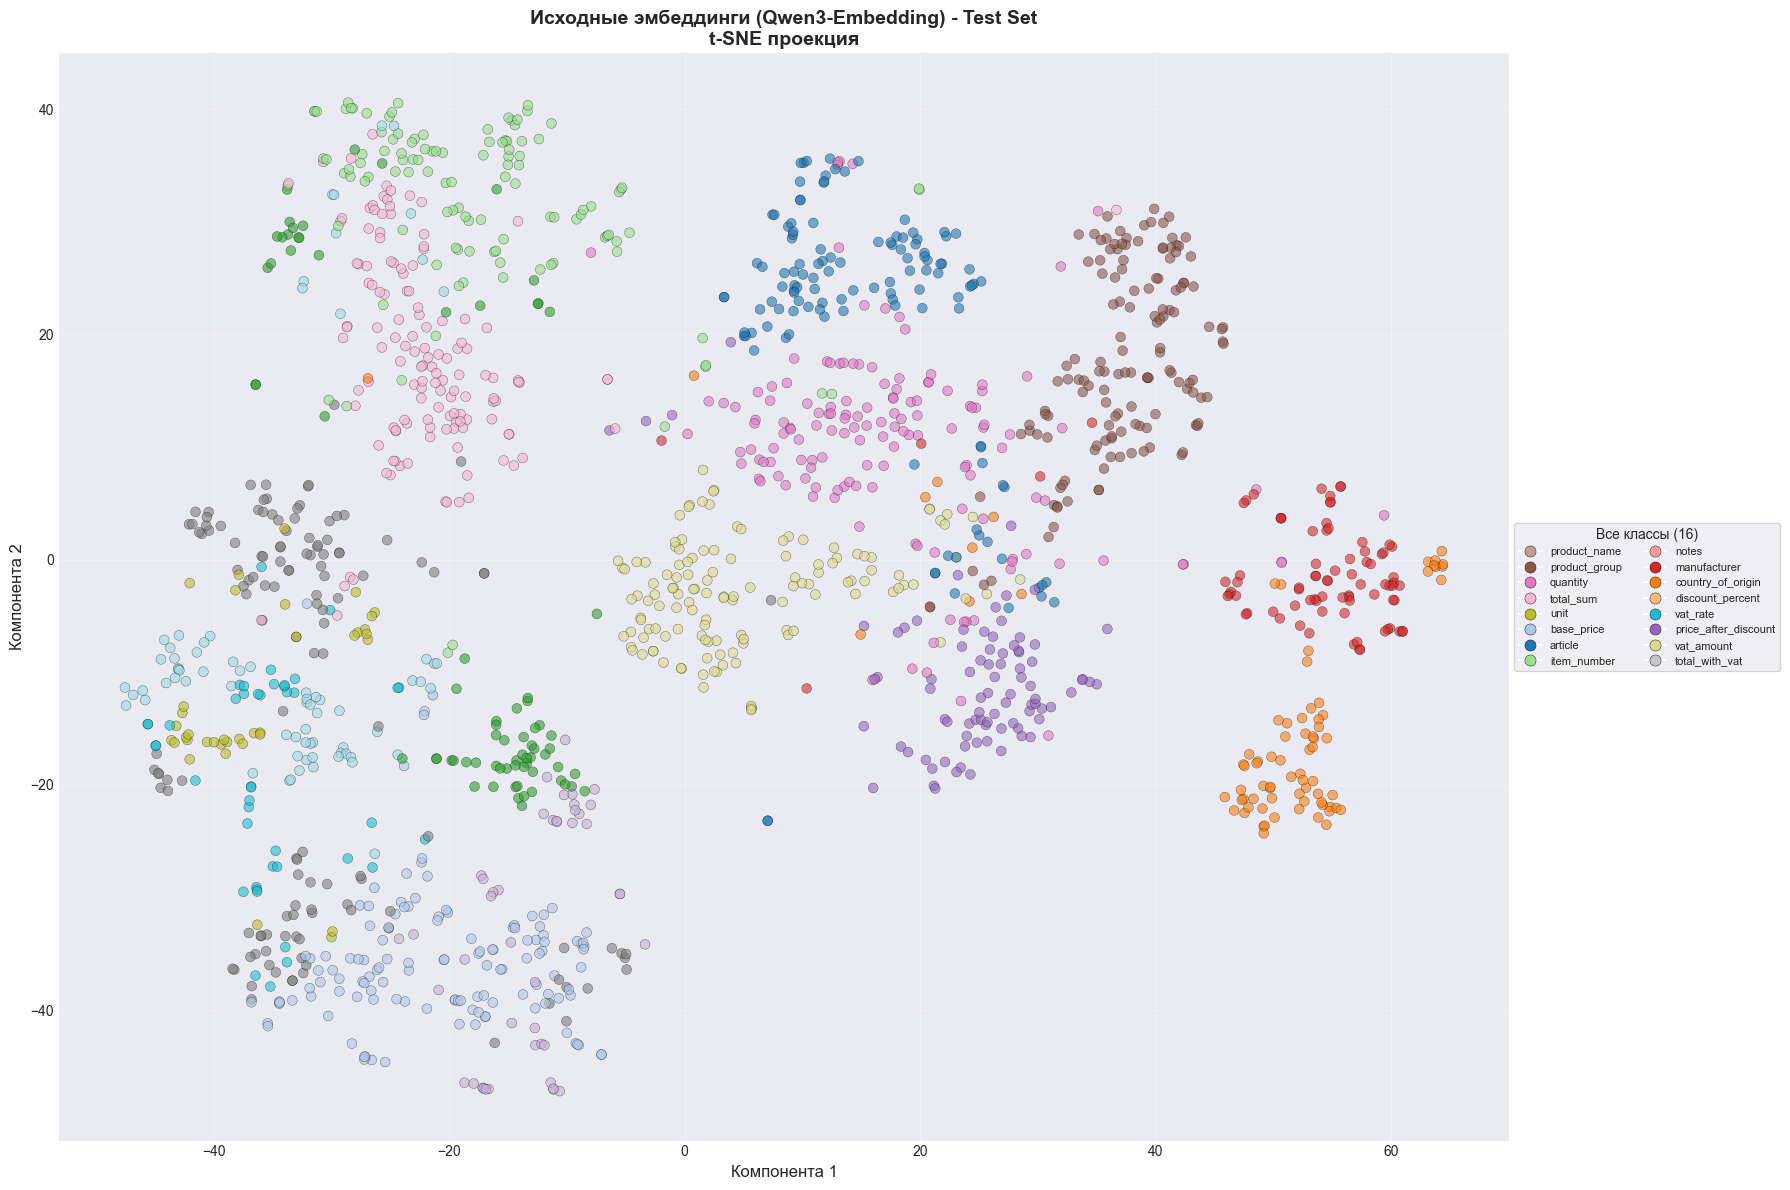

✅ Сохранено: 01_original_embeddings_tsne.png


In [10]:
# t-SNE для визуализации исходных эмбеддингов (используем test set)
print("🔄 Запуск t-SNE для исходных эмбеддингов (test set)...")

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_test)-1))
coords_original = tsne.fit_transform(X_test)

print("✅ t-SNE завершён")

# Визуализация
fig, ax = plt.subplots(figsize=(18, 12))
scatter = ax.scatter(coords_original[:, 0], coords_original[:, 1], 
                     c=y_test, cmap='tab20', s=50, alpha=0.6, edgecolors='black', linewidth=0.3)

ax.set_title('Исходные эмбеддинги (Qwen3-Embedding) - Test Set\nt-SNE проекция', 
         fontsize=14, fontweight='bold')
ax.set_xlabel('Компонента 1', fontsize=12)
ax.set_ylabel('Компонента 2', fontsize=12)
ax.grid(alpha=0.3)

# Легенда с названиями ВСЕХ классов
idx_to_label = {v: k for k, v in label_to_idx.items()}
unique_test_labels = np.unique(y_test)
label_counts = Counter(y_test)
all_labels = sorted(unique_test_labels, key=lambda x: label_counts[x], reverse=True)  # Сортируем по частоте

handles = []
for label_idx in all_labels:
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                             markerfacecolor=plt.cm.tab20(label_idx / len(label_to_idx)), 
                             markersize=8, label=idx_to_label[label_idx][:30],
                             markeredgecolor='black', markeredgewidth=0.3))
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5), 
         fontsize=8, frameon=True, fancybox=True, title=f'Все классы ({len(all_labels)})', ncol=2)

plt.tight_layout()
plt.savefig('01_original_embeddings_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: 01_original_embeddings_tsne.png")

## 5️⃣ Метрики разделимости исходных эмбеддингов

In [11]:
# Вычисляем метрики разделимости для исходных эмбеддингов
def compute_separability_metrics(embeddings, labels):
    """Вычисление метрик разделимости"""
    unique_labels = np.unique(labels)
    
    # Вычисляем внутриклассовое и межклассовое сходство
    intra_class_sims = []
    inter_class_sims = []
    
    for label in unique_labels:
        # Эмбеддинги текущего класса
        class_mask = labels == label
        class_embs = embeddings[class_mask]
        
        if len(class_embs) > 1:
            # Внутриклассовое сходство
            sims = cosine_similarity(class_embs)
            mask = ~np.eye(len(class_embs), dtype=bool)
            intra_class_sims.extend(sims[mask].flatten())
        
        # Межклассовое сходство
        other_mask = ~class_mask
        if other_mask.sum() > 0:
            other_embs = embeddings[other_mask]
            sims = cosine_similarity(class_embs, other_embs)
            inter_class_sims.extend(sims.flatten())
    
    intra_mean = np.mean(intra_class_sims)
    inter_mean = np.mean(inter_class_sims)
    separability = intra_mean - inter_mean
    
    return {
        'intra_class_similarity': intra_mean,
        'inter_class_similarity': inter_mean,
        'separability': separability
    }

metrics_original = compute_separability_metrics(X_test, y_test)

print("📊 МЕТРИКИ ИСХОДНЫХ ЭМБЕДДИНГОВ (Test Set):")
print("="*60)
print(f"  Внутриклассовое сходство: {metrics_original['intra_class_similarity']:.4f}")
print(f"  Межклассовое сходство:    {metrics_original['inter_class_similarity']:.4f}")
print(f"  Разделимость:             {metrics_original['separability']:.4f}")
print("="*60)
print("💡 Чем выше разделимость, тем лучше модель различает классы")

📊 МЕТРИКИ ИСХОДНЫХ ЭМБЕДДИНГОВ (Test Set):
  Внутриклассовое сходство: 0.5403
  Межклассовое сходство:    0.3900
  Разделимость:             0.1503
💡 Чем выше разделимость, тем лучше модель различает классы


## 6️⃣ Создание PyTorch Dataset (упрощенный для pytorch-metric-learning)

In [12]:
class EmbeddingDataset(Dataset):
    """Простой dataset для эмбеддингов и меток (pytorch-metric-learning сам создаст триплеты)"""
    
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

# Создание datasets
train_dataset = EmbeddingDataset(X_train, y_train)
val_dataset = EmbeddingDataset(X_val, y_val)
test_dataset = EmbeddingDataset(X_test, y_test)

# Создание dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ Datasets созданы:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

✅ Datasets созданы:
  Train batches: 114
  Val batches:   25
  Test batches:  25


## 7️⃣ Модель проекции

In [13]:
class ProjectionHead(nn.Module):
    """Простая линейная проекция эмбеддингов"""
    
    def __init__(self, input_dim=QWEN_DIM, output_dim=OUTPUT_DIM):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)

# Создание или загрузка модели
model = ProjectionHead().to(device)

# Попытка загрузить предобученную модель
LOAD_PRETRAINED = False  # Установите False если хотите обучить с нуля
model_loaded = False

if LOAD_PRETRAINED and MODEL_PATH.exists():
    try:
        print(f"📥 Загрузка предобученной модели из {MODEL_PATH}...")
        checkpoint = torch.load(MODEL_PATH, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model_loaded = True
        
        print("✅ Предобученная модель загружена успешно!")
        print(f"   Input dim: {checkpoint.get('input_dim', 'N/A')}")
        print(f"   Output dim: {checkpoint.get('output_dim', 'N/A')}")
        
        # Безопасная загрузка метрик
        best_val_loss_from_checkpoint = checkpoint.get('best_val_loss', 0.0)
        if best_val_loss_from_checkpoint > 0:
            print(f"   Best val loss: {best_val_loss_from_checkpoint:.4f}")
        
        metrics_new_from_checkpoint = checkpoint.get('metrics_new', {})
        if metrics_new_from_checkpoint:
            sep_improvement = metrics_new_from_checkpoint.get('separability', None)
            if sep_improvement is not None:
                print(f"   Separability: {sep_improvement:.4f}")
        
        print("\n💡 Основное обучение будет пропущено. Перейдем к Few-Shot экспериментам.")
    except Exception as e:
        print(f"⚠️  Ошибка при загрузке модели: {e}")
        print("   Начнем обучение с нуля...")
        model_loaded = False
else:
    if LOAD_PRETRAINED:
        print(f"📝 Предобученная модель не найдена: {MODEL_PATH}")
        print("   Начнем обучение с нуля...")
    else:
        print("🔧 Режим обучения с нуля (LOAD_PRETRAINED=False)")

print("\n🔧 Модель:")
print(model)
print(f"Параметры: {sum(p.numel() for p in model.parameters()):,}")

🔧 Режим обучения с нуля (LOAD_PRETRAINED=False)

🔧 Модель:
ProjectionHead(
  (linear): Linear(in_features=4096, out_features=4096, bias=True)
)
Параметры: 16,781,312


## 8️⃣ Loss функция, Miner и оптимизатор

### 💡 О выборе Loss функции

**Почему TripletMarginLoss + AvgNonZeroReducer:**
- **TripletMarginLoss**: Классический triplet loss для metric learning
- **AvgNonZeroReducer**: Усредняет только триплеты с loss > 0 (игнорирует уже хорошие пары)
- Альтернативы: `ContrastiveLoss`, `NTXentLoss`, `SupConLoss`

**Почему не ThresholdReducer(low=0):**
- Отбрасывает ВСЕ триплеты с loss=0
- Может привести к пустому batch → loss=0 → нет обучения

**Почему MultiSimilarityMiner:**
- Находит hard negatives и hard positives
- Более эффективен чем случайные триплеты

In [14]:
# Distance metric (cosine distance)
distance = distances.CosineSimilarity()

# Triplet Margin Loss с pytorch-metric-learning
# AvgNonZeroReducer - усредняет только ненулевые losses (лучше для обучения)
criterion = losses.TripletMarginLoss(
    margin=MARGIN,
    distance=distance,
    reducer=reducers.AvgNonZeroReducer()  # Игнорирует триплеты с loss=0
)

# Miner для выбора hard triplets (более эффективное обучение)
# MultiSimilarityMiner находит наиболее информативные триплеты
miner = miners.MultiSimilarityMiner(epsilon=MARGIN)

# Оптимизатор
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print("✅ Оптимизатор и loss настроены:")
print(f"  Loss: TripletMarginLoss (margin={MARGIN}, cosine distance)")
print(f"  Reducer: AvgNonZeroReducer (усредняет только ненулевые losses)")
print(f"  Miner: MultiSimilarityMiner (hard triplet mining)")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Scheduler: ReduceLROnPlateau")

✅ Оптимизатор и loss настроены:
  Loss: TripletMarginLoss (margin=0.2, cosine distance)
  Reducer: AvgNonZeroReducer (усредняет только ненулевые losses)
  Miner: MultiSimilarityMiner (hard triplet mining)
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau


## 9️⃣ Обучение модели

In [15]:
# Обучение модели (пропускаем если загружена предобученная)
if not model_loaded:
    # История обучения
    history = {
        'train_loss': [],
        'val_loss': []
    }

    best_val_loss = float('inf')
    best_model_state = None

    print("🚀 Начало обучения...")
    print("="*80)

    for epoch in range(EPOCHS):
        # Training
        model.train()
        train_loss = 0.0
        
        for batch_idx, (embeddings_batch, labels_batch) in enumerate(train_loader):
            embeddings_batch = embeddings_batch.to(device)
            labels_batch = labels_batch.to(device)
            
            # Forward pass
            embeddings_out = model(embeddings_batch)
            
            # Mining hard triplets
            hard_pairs = miner(embeddings_out, labels_batch)
            
            # Loss (только на hard triplets)
            loss = criterion(embeddings_out, labels_batch, hard_pairs)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for embeddings_batch, labels_batch in val_loader:
                embeddings_batch = embeddings_batch.to(device)
                labels_batch = labels_batch.to(device)
                
                embeddings_out = model(embeddings_batch)
                hard_pairs = miner(embeddings_out, labels_batch)
                loss = criterion(embeddings_out, labels_batch, hard_pairs)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        
        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        # Scheduler step
        scheduler.step(val_loss)
        
        # Сохранение лучшей модели
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            print(f"Epoch {epoch+1:3d}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f} 🌟 (Best)")
        else:
            print(f"Epoch {epoch+1:3d}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    print("\n" + "="*80)
    print("✅ Обучение завершено!")
    print(f"   Лучший Val Loss: {best_val_loss:.4f}")

    # Загружаем лучшую модель
    model.load_state_dict(best_model_state)
    print("✅ Загружена лучшая модель")
else:
    print("⏭️  Обучение пропущено - используется предобученная модель")
    # Создаем пустую историю для совместимости
    history = {'train_loss': [], 'val_loss': []}
    # Загружаем best_val_loss из checkpoint если есть
    try:
        checkpoint = torch.load(MODEL_PATH, map_location=device)
        best_val_loss = checkpoint.get('best_val_loss', 0.0)
    except:
        best_val_loss = 0.0

🚀 Начало обучения...
Epoch   1: Train Loss=0.1571, Val Loss=0.1801 🌟 (Best)
Epoch   2: Train Loss=0.1413, Val Loss=0.1465 🌟 (Best)
Epoch   3: Train Loss=0.1344, Val Loss=0.1459 🌟 (Best)
Epoch   4: Train Loss=0.1282, Val Loss=0.1446 🌟 (Best)
Epoch   5: Train Loss=0.1231, Val Loss=0.1467
Epoch   6: Train Loss=0.1163, Val Loss=0.1485
Epoch   7: Train Loss=0.1155, Val Loss=0.1407 🌟 (Best)
Epoch   8: Train Loss=0.1126, Val Loss=0.1528
Epoch   9: Train Loss=0.1059, Val Loss=0.1489
Epoch  10: Train Loss=0.1069, Val Loss=0.1481

✅ Обучение завершено!
   Лучший Val Loss: 0.1407
✅ Загружена лучшая модель


## 🔟 График обучения

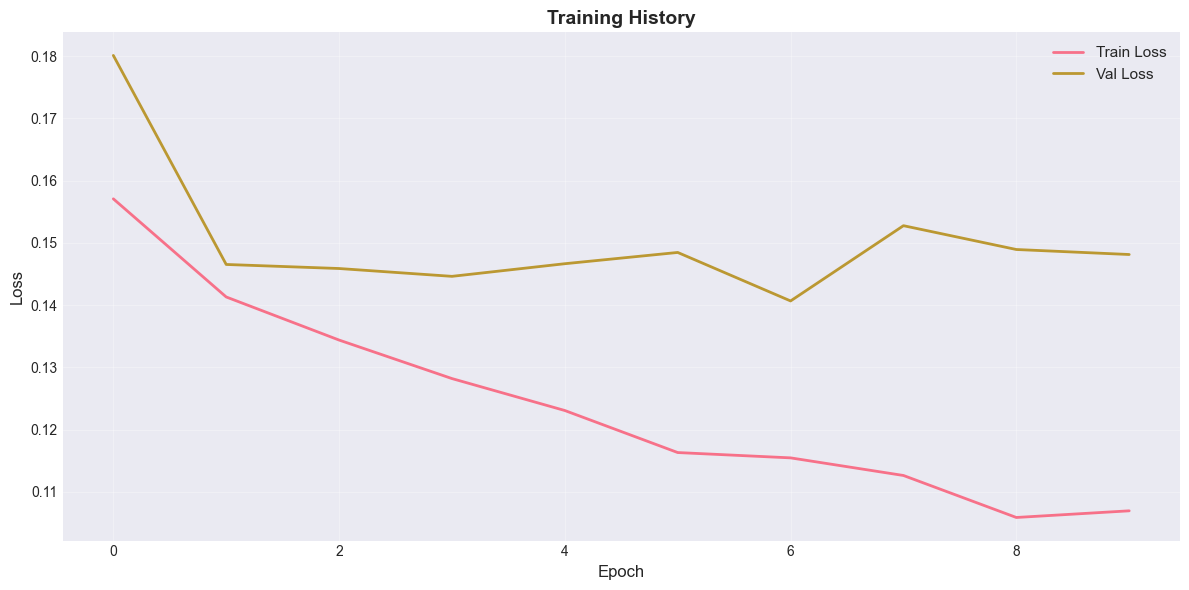

✅ Сохранено: 02_training_history.png


In [16]:
# Построение графика только если есть история обучения
if history['train_loss'] and history['val_loss']:
    plt.figure(figsize=(12, 6))
    plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
    plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training History', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('02_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: 02_training_history.png")
else:
    print("⏭️  График обучения пропущен - модель была загружена, обучения не было")

## 1️⃣1️⃣ Получение новых эмбеддингов

In [17]:
# Прогоняем test set через модель
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    X_test_projected = model(X_test_tensor).cpu().numpy()

print(f"✅ Новые эмбеддинги получены:")
print(f"  Размерность: {X_test_projected.shape}")
print(f"  Исходная:    {X_test.shape}")

✅ Новые эмбеддинги получены:
  Размерность: (1561, 4096)
  Исходная:    (1561, 4096)


## 1️⃣2️⃣ Визуализация новых эмбеддингов (t-SNE)

🔄 Запуск t-SNE для новых эмбеддингов (test set)...
✅ t-SNE завершён


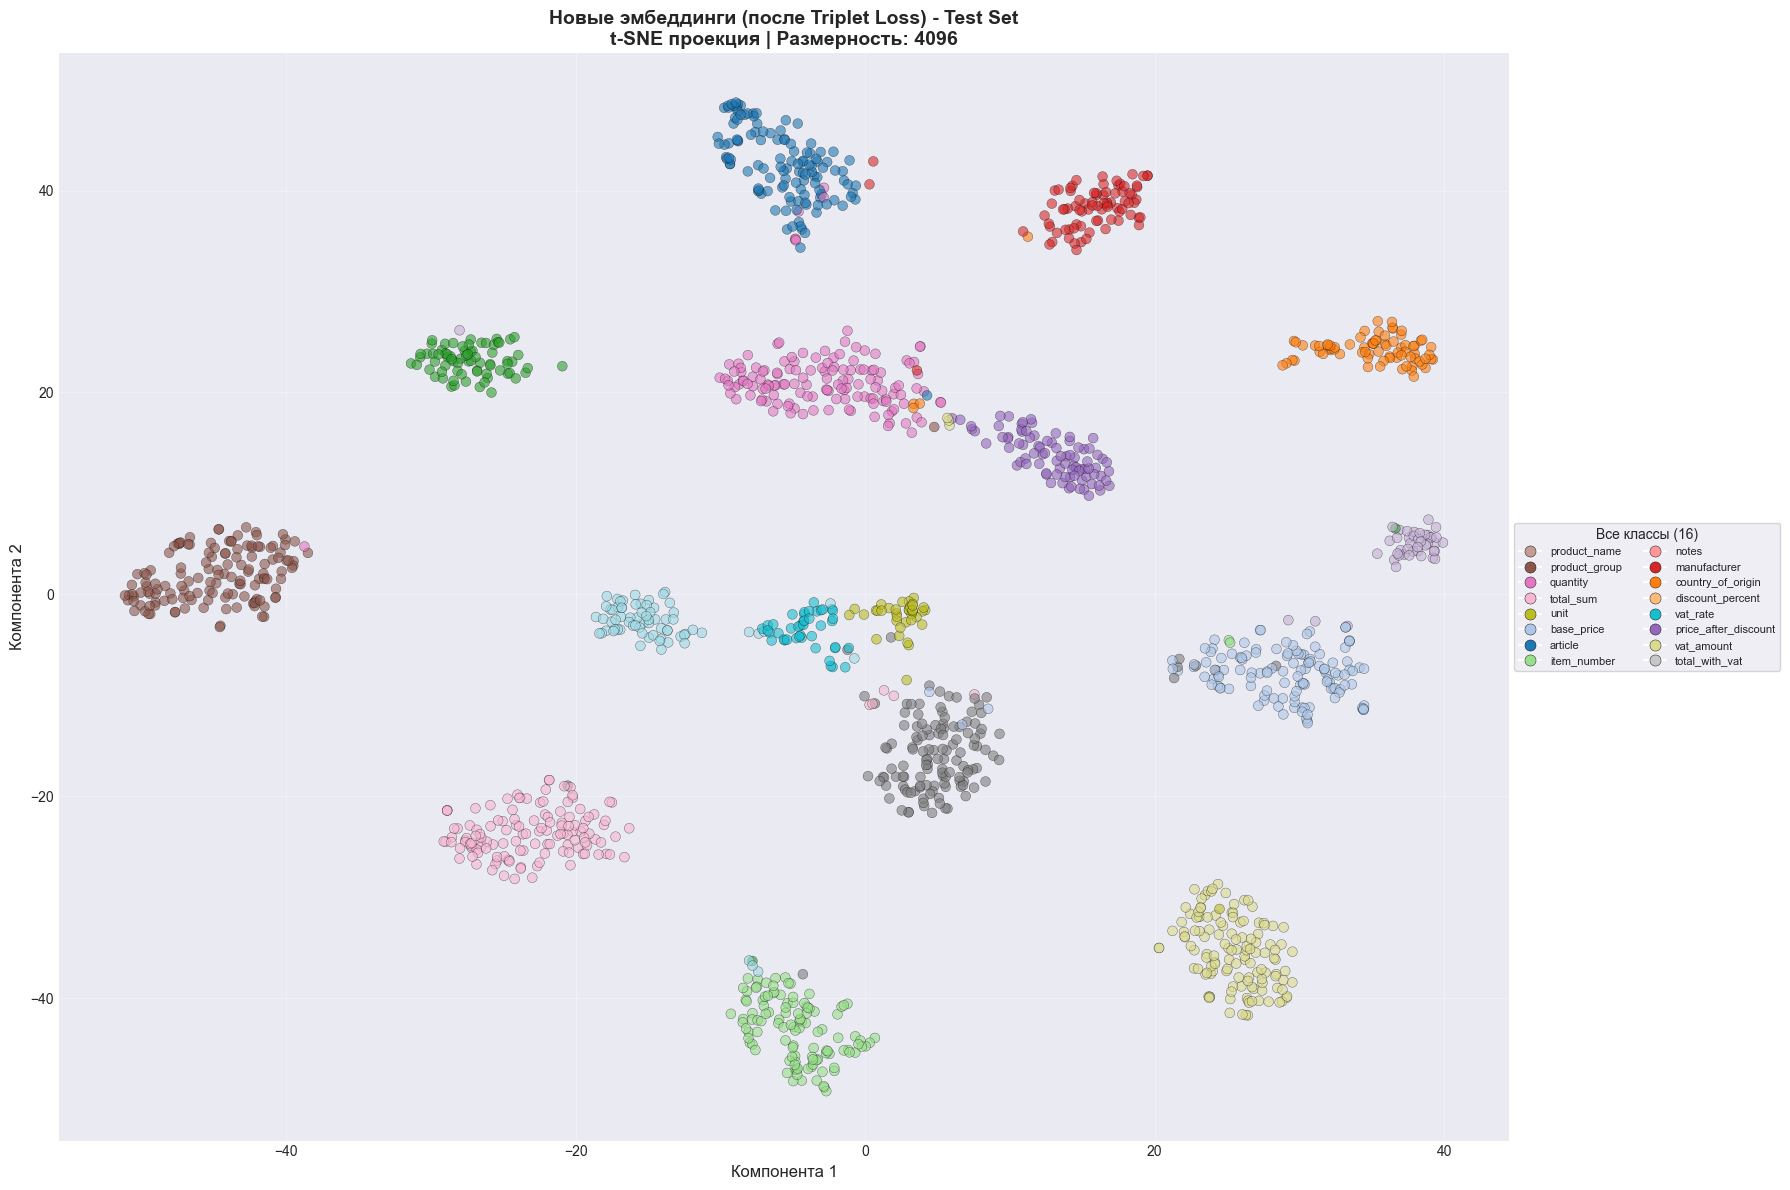

✅ Сохранено: 03_new_embeddings_tsne.png


In [18]:
# t-SNE для новых эмбеддингов
print("🔄 Запуск t-SNE для новых эмбеддингов (test set)...")

tsne_new = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_test_projected)-1))
coords_new = tsne_new.fit_transform(X_test_projected)

print("✅ t-SNE завершён")

# Визуализация
fig, ax = plt.subplots(figsize=(18, 12))
scatter = ax.scatter(coords_new[:, 0], coords_new[:, 1], 
                     c=y_test, cmap='tab20', s=50, alpha=0.6, edgecolors='black', linewidth=0.3)

ax.set_title(f'Новые эмбеддинги (после Triplet Loss) - Test Set\nt-SNE проекция | Размерность: {OUTPUT_DIM}', 
         fontsize=14, fontweight='bold')
ax.set_xlabel('Компонента 1', fontsize=12)
ax.set_ylabel('Компонента 2', fontsize=12)
ax.grid(alpha=0.3)

# Легенда с названиями ВСЕХ классов
idx_to_label = {v: k for k, v in label_to_idx.items()}
label_counts = Counter(y_test)
all_labels = sorted(np.unique(y_test), key=lambda x: label_counts[x], reverse=True)  # Все классы, сортированные по частоте

handles = []
for label_idx in all_labels:
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                             markerfacecolor=plt.cm.tab20(label_idx / len(label_to_idx)), 
                             markersize=8, label=idx_to_label[label_idx][:30],
                             markeredgecolor='black', markeredgewidth=0.3))
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5), 
         fontsize=8, frameon=True, fancybox=True, title=f'Все классы ({len(all_labels)})', ncol=2)

plt.tight_layout()
plt.savefig('03_new_embeddings_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: 03_new_embeddings_tsne.png")

## 1️⃣3️⃣ Сравнение метрик до/после

In [19]:
# Метрики для новых эмбеддингов
metrics_new = compute_separability_metrics(X_test_projected, y_test)

print("📊 СРАВНЕНИЕ МЕТРИК (Test Set):")
print("="*80)
print(f"\n{'Метрика':<30} {'Исходные':>12} {'Новые':>12} {'Улучшение':>15}")
print("-"*80)

# Внутриклассовое сходство (должно увеличиться)
intra_orig = metrics_original['intra_class_similarity']
intra_new = metrics_new['intra_class_similarity']
intra_improve = ((intra_new - intra_orig) / abs(intra_orig)) * 100
print(f"{'Внутриклассовое сходство':<30} {intra_orig:>12.4f} {intra_new:>12.4f} {intra_improve:>14.2f}%")

# Межклассовое сходство (должно уменьшиться)
inter_orig = metrics_original['inter_class_similarity']
inter_new = metrics_new['inter_class_similarity']
inter_improve = ((inter_orig - inter_new) / abs(inter_orig)) * 100
print(f"{'Межклассовое сходство':<30} {inter_orig:>12.4f} {inter_new:>12.4f} {inter_improve:>14.2f}%")

# Разделимость (должна увеличиться)
sep_orig = metrics_original['separability']
sep_new = metrics_new['separability']
sep_improve = ((sep_new - sep_orig) / abs(sep_orig)) * 100
print(f"{'Разделимость':<30} {sep_orig:>12.4f} {sep_new:>12.4f} {sep_improve:>14.2f}%")

print("="*80)
print("\n💡 Интерпретация:")
print(f"  - Внутриклассовое сходство {'↑' if intra_improve > 0 else '↓'} на {abs(intra_improve):.2f}%")
print(f"  - Межклассовое сходство {'↓' if inter_improve > 0 else '↑'} на {abs(inter_improve):.2f}%")
print(f"  - Разделимость {'↑' if sep_improve > 0 else '↓'} на {abs(sep_improve):.2f}%")

if sep_improve > 0:
    print("\n✅ Модель успешно улучшила разделимость классов!")
else:
    print("\n⚠️  Модель не улучшила разделимость. Попробуйте:")
    print("    - Увеличить количество эпох")
    print("    - Изменить learning rate")
    print("    - Изменить margin в Triplet Loss")
    print("    - Использовать более сложную архитектуру")

📊 СРАВНЕНИЕ МЕТРИК (Test Set):

Метрика                            Исходные        Новые       Улучшение
--------------------------------------------------------------------------------
Внутриклассовое сходство             0.5403       0.8047          48.94%
Межклассовое сходство                0.3900      -0.0144         103.70%
Разделимость                         0.1503       0.8191         445.13%

💡 Интерпретация:
  - Внутриклассовое сходство ↑ на 48.94%
  - Межклассовое сходство ↓ на 103.70%
  - Разделимость ↑ на 445.13%

✅ Модель успешно улучшила разделимость классов!


## 1️⃣3️⃣b Метрики Precision@K (pytorch-metric-learning)

In [20]:
# Вычисление Precision@K с помощью AccuracyCalculator
def compute_accuracy_metrics(embeddings, labels, model_name="Model"):
    """Вычисление Precision@K метрик"""
    # Используем только доступные метрики (без precision_at_5)
    accuracy_calculator = AccuracyCalculator(
        include=("precision_at_1", "r_precision", "mean_average_precision_at_r", "mean_average_precision"),
        k=5
    )
    
    # Преобразуем в torch tensors
    embeddings_tensor = torch.FloatTensor(embeddings)
    labels_tensor = torch.LongTensor(labels)
    
    # Вычисляем метрики
    # query и reference - одинаковые (используем тот же датасет для поиска)
    accuracies = accuracy_calculator.get_accuracy(
        query=embeddings_tensor,
        reference=embeddings_tensor,
        query_labels=labels_tensor,
        reference_labels=labels_tensor
    )
    
    return accuracies

# Метрики для исходных эмбеддингов
print("🔄 Вычисление Precision@K для исходных эмбеддингов...")
accuracies_original = compute_accuracy_metrics(X_test, y_test, "Original")

# Метрики для новых эмбеддингов  
print("🔄 Вычисление Precision@K для новых эмбеддингов...")
accuracies_new = compute_accuracy_metrics(X_test_projected, y_test, "New")

print("\n📊 МЕТРИКИ RETRIEVAL (Test Set):")
print("="*80)
print(f"\n{'Метрика':<35} {'Исходные':>12} {'Новые':>12} {'Улучшение':>15}")
print("-"*80)

for metric_name in ['precision_at_1', 'r_precision', 'mean_average_precision_at_r', 'mean_average_precision']:
    orig_val = accuracies_original[metric_name]
    new_val = accuracies_new[metric_name]
    improve = ((new_val - orig_val) / abs(orig_val)) * 100 if orig_val != 0 else 0
    
    display_name = metric_name.replace('_', ' ').title()
    print(f"{display_name:<35} {orig_val:>12.4f} {new_val:>12.4f} {improve:>14.2f}%")

print("="*80)
print("\n💡 Precision@1 - точность ближайшего соседа")
print("   R-Precision - precision для R ближайших (R = кол-во примеров класса)")
print("   MAP@R - средняя точность по всем релевантным примерам")


If you're looking for MAP@5 instead of MAP@R, then you should use 'mean_average_precision' rather than mean_average_precision_at_r


🔄 Вычисление Precision@K для исходных эмбеддингов...
🔄 Вычисление Precision@K для новых эмбеддингов...



If you're looking for MAP@5 instead of MAP@R, then you should use 'mean_average_precision' rather than mean_average_precision_at_r



📊 МЕТРИКИ RETRIEVAL (Test Set):

Метрика                                 Исходные        Новые       Улучшение
--------------------------------------------------------------------------------
Precision At 1                            1.0000       1.0000           0.00%
R Precision                               0.8627       0.9595          11.23%
Mean Average Precision At R               0.0424       0.0485          14.50%
Mean Average Precision                    0.0424       0.0485          14.50%

💡 Precision@1 - точность ближайшего соседа
   R-Precision - precision для R ближайших (R = кол-во примеров класса)
   MAP@R - средняя точность по всем релевантным примерам


## 1️⃣4️⃣ Графики FAR и FRR (False Accept/Reject Rate)

In [21]:
# Вычисление FAR и FRR для разных порогов
def compute_far_frr(embeddings, labels):
    """
    Вычисление False Accept Rate (FAR) и False Reject Rate (FRR)
    FAR - процент неправильно принятых пар (разные классы, но сходство > порог)
    FRR - процент неправильно отклоненных пар (один класс, но сходство < порог)
    """
    # Вычисляем матрицу косинусного сходства
    similarity_matrix = cosine_similarity(embeddings)
    n = len(labels)
    
    # Создаем маску для genuine pairs (одинаковый класс)
    genuine_mask = np.zeros((n, n), dtype=bool)
    for i in range(n):
        for j in range(i+1, n):
            if labels[i] == labels[j]:
                genuine_mask[i, j] = True
                genuine_mask[j, i] = True
    
    # Извлекаем genuine и impostor scores
    genuine_scores = similarity_matrix[genuine_mask]
    impostor_scores = similarity_matrix[~genuine_mask & ~np.eye(n, dtype=bool)]
    
    # Пороги от минимального до максимального сходства
    thresholds = np.linspace(
        min(genuine_scores.min(), impostor_scores.min()),
        max(genuine_scores.max(), impostor_scores.max()),
        200
    )
    
    far_values = []
    frr_values = []
    
    for threshold in thresholds:
        # FAR: доля impostor pairs со сходством >= threshold
        far = np.sum(impostor_scores >= threshold) / len(impostor_scores)
        
        # FRR: доля genuine pairs со сходством < threshold
        frr = np.sum(genuine_scores < threshold) / len(genuine_scores)
        
        far_values.append(far)
        frr_values.append(frr)
    
    # Находим Equal Error Rate (EER) - точка пересечения FAR и FRR
    eer_idx = np.argmin(np.abs(np.array(far_values) - np.array(frr_values)))
    eer = (far_values[eer_idx] + frr_values[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]
    
    return {
        'thresholds': thresholds,
        'far': np.array(far_values),
        'frr': np.array(frr_values),
        'eer': eer,
        'eer_threshold': eer_threshold,
        'genuine_scores': genuine_scores,
        'impostor_scores': impostor_scores
    }

print("🔄 Вычисление FAR/FRR для исходных эмбеддингов...")
far_frr_original = compute_far_frr(X_test, y_test)

print("🔄 Вычисление FAR/FRR для новых эмбеддингов...")
far_frr_new = compute_far_frr(X_test_projected, y_test)

print(f"\n📊 Equal Error Rate (EER):")
print(f"  Исходные эмбеддинги: {far_frr_original['eer']:.4f} (порог: {far_frr_original['eer_threshold']:.4f})")
print(f"  Новые эмбеддинги:    {far_frr_new['eer']:.4f} (порог: {far_frr_new['eer_threshold']:.4f})")
print(f"\n💡 EER - чем ниже, тем лучше разделимость классов")

🔄 Вычисление FAR/FRR для исходных эмбеддингов...
🔄 Вычисление FAR/FRR для новых эмбеддингов...

📊 Equal Error Rate (EER):
  Исходные эмбеддинги: 0.2662 (порог: 0.4460)
  Новые эмбеддинги:    0.0312 (порог: 0.4138)

💡 EER - чем ниже, тем лучше разделимость классов


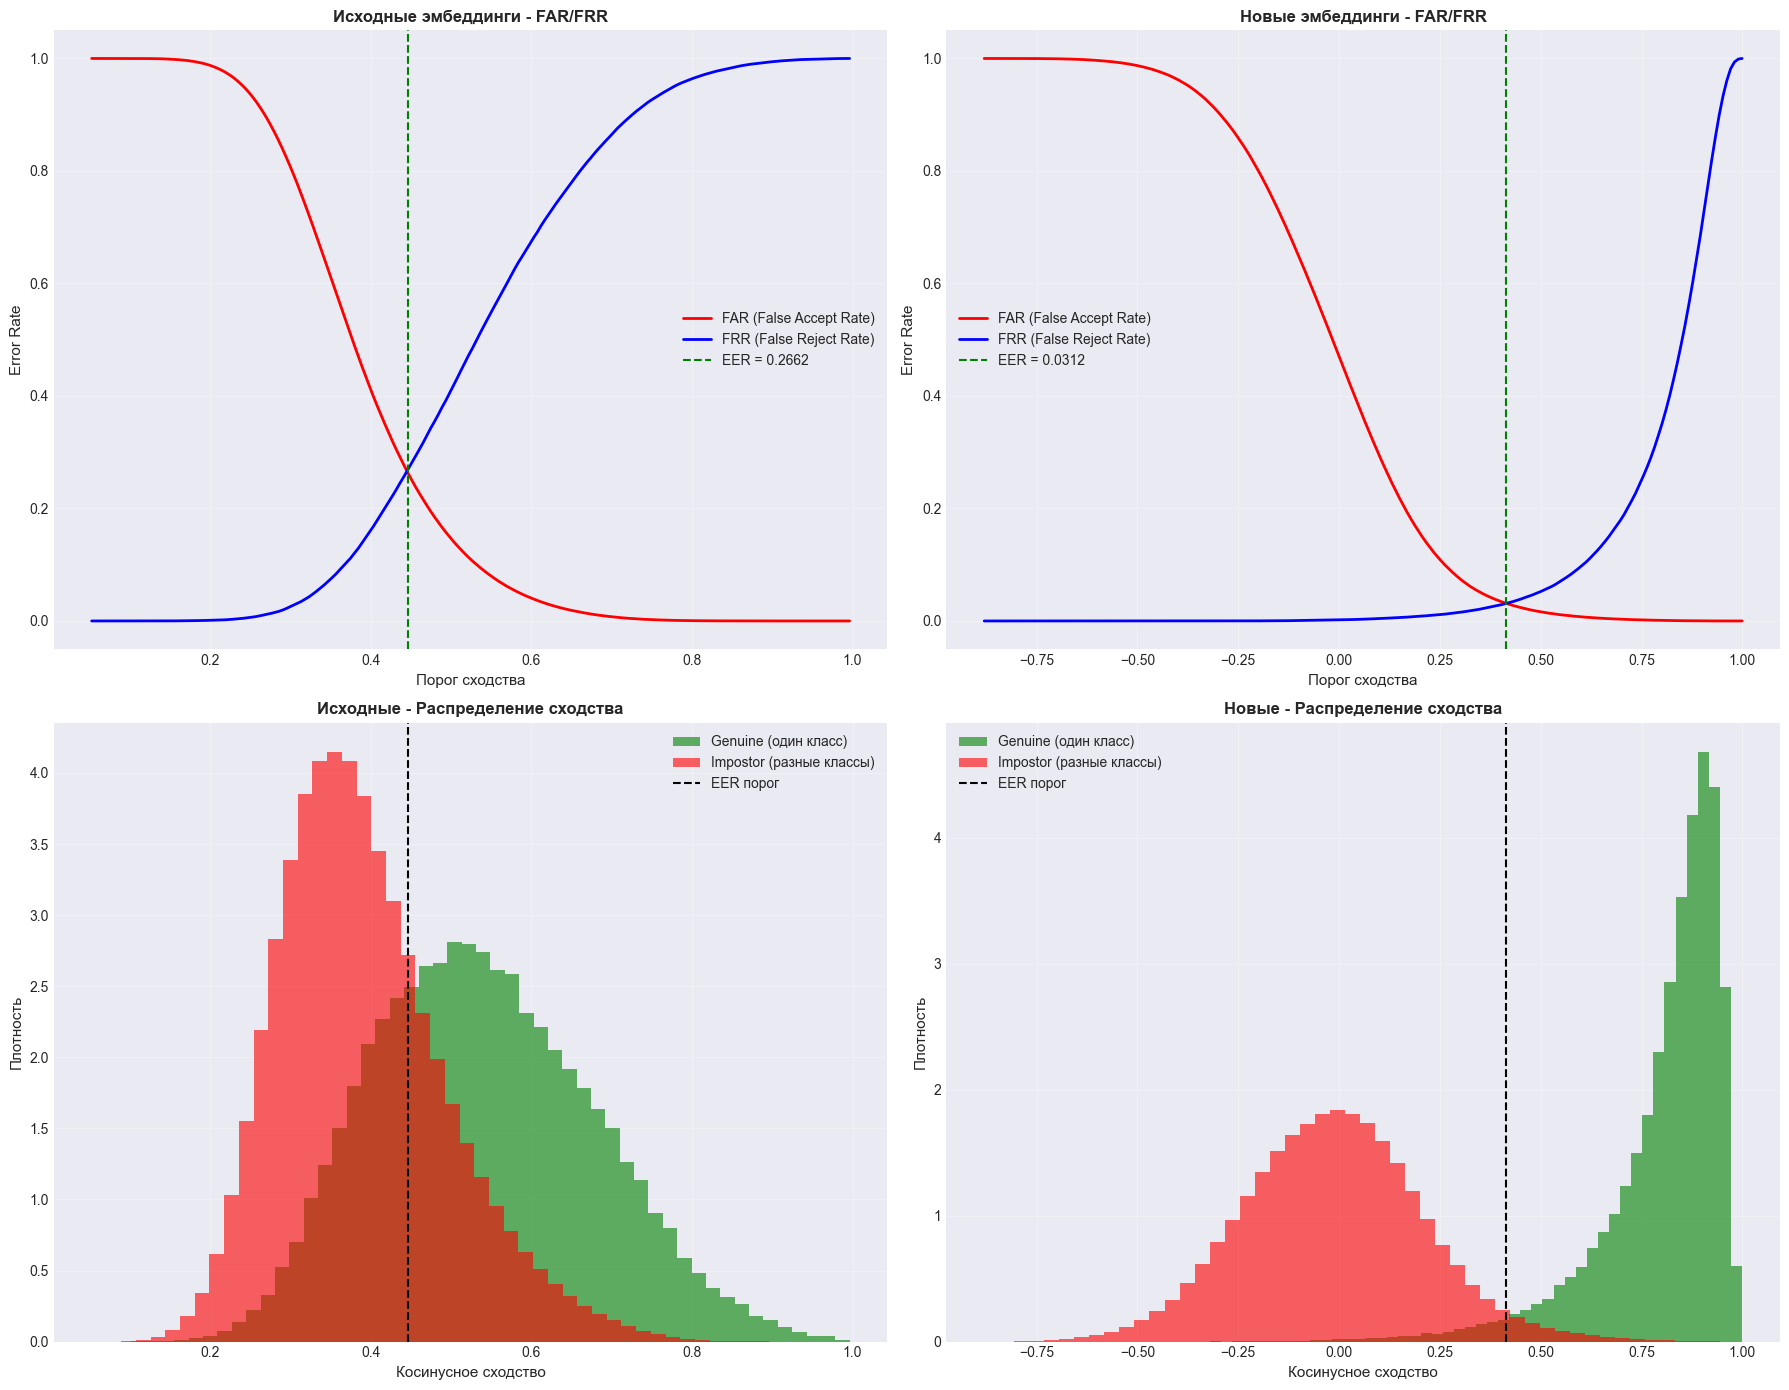

✅ Сохранено: 05_far_frr_analysis.png

📊 СТАТИСТИКА РАСПРЕДЕЛЕНИЙ:

Метрика                                    Исходные                Новые
--------------------------------------------------------------------------------
Genuine mean                                 0.5403               0.8047
Genuine std                                  0.1375               0.1547
Impostor mean                                0.3900              -0.0144
Impostor std                                 0.1047               0.2225
Separation (G-I)                             0.1503               0.8191

💡 Separation (G-I) - разница между средними genuine и impostor
   Чем больше → тем лучше модель разделяет классы


In [22]:
# Визуализация FAR/FRR кривых
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. FAR/FRR для исходных эмбеддингов
ax = axes[0, 0]
ax.plot(far_frr_original['thresholds'], far_frr_original['far'], 
        label='FAR (False Accept Rate)', linewidth=2, color='red')
ax.plot(far_frr_original['thresholds'], far_frr_original['frr'], 
        label='FRR (False Reject Rate)', linewidth=2, color='blue')
ax.axvline(far_frr_original['eer_threshold'], color='green', linestyle='--', 
          label=f'EER = {far_frr_original["eer"]:.4f}', linewidth=1.5)
ax.set_xlabel('Порог сходства', fontsize=11)
ax.set_ylabel('Error Rate', fontsize=11)
ax.set_title('Исходные эмбеддинги - FAR/FRR', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 2. FAR/FRR для новых эмбеддингов
ax = axes[0, 1]
ax.plot(far_frr_new['thresholds'], far_frr_new['far'], 
        label='FAR (False Accept Rate)', linewidth=2, color='red')
ax.plot(far_frr_new['thresholds'], far_frr_new['frr'], 
        label='FRR (False Reject Rate)', linewidth=2, color='blue')
ax.axvline(far_frr_new['eer_threshold'], color='green', linestyle='--', 
          label=f'EER = {far_frr_new["eer"]:.4f}', linewidth=1.5)
ax.set_xlabel('Порог сходства', fontsize=11)
ax.set_ylabel('Error Rate', fontsize=11)
ax.set_title('Новые эмбеддинги - FAR/FRR', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 3. Распределение genuine vs impostor scores (исходные)
ax = axes[1, 0]
ax.hist(far_frr_original['genuine_scores'], bins=50, alpha=0.6, 
        label='Genuine (один класс)', color='green', density=True)
ax.hist(far_frr_original['impostor_scores'], bins=50, alpha=0.6, 
        label='Impostor (разные классы)', color='red', density=True)
ax.axvline(far_frr_original['eer_threshold'], color='black', linestyle='--', 
          label=f'EER порог', linewidth=1.5)
ax.set_xlabel('Косинусное сходство', fontsize=11)
ax.set_ylabel('Плотность', fontsize=11)
ax.set_title('Исходные - Распределение сходства', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 4. Распределение genuine vs impostor scores (новые)
ax = axes[1, 1]
ax.hist(far_frr_new['genuine_scores'], bins=50, alpha=0.6, 
        label='Genuine (один класс)', color='green', density=True)
ax.hist(far_frr_new['impostor_scores'], bins=50, alpha=0.6, 
        label='Impostor (разные классы)', color='red', density=True)
ax.axvline(far_frr_new['eer_threshold'], color='black', linestyle='--', 
          label=f'EER порог', linewidth=1.5)
ax.set_xlabel('Косинусное сходство', fontsize=11)
ax.set_ylabel('Плотность', fontsize=11)
ax.set_title('Новые - Распределение сходства', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('05_far_frr_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: 05_far_frr_analysis.png")

# Дополнительная информация
print("\n📊 СТАТИСТИКА РАСПРЕДЕЛЕНИЙ:")
print("="*80)
print(f"\n{'Метрика':<30} {'Исходные':>20} {'Новые':>20}")
print("-"*80)

metrics_to_show = [
    ('Genuine mean', far_frr_original['genuine_scores'].mean(), far_frr_new['genuine_scores'].mean()),
    ('Genuine std', far_frr_original['genuine_scores'].std(), far_frr_new['genuine_scores'].std()),
    ('Impostor mean', far_frr_original['impostor_scores'].mean(), far_frr_new['impostor_scores'].mean()),
    ('Impostor std', far_frr_original['impostor_scores'].std(), far_frr_new['impostor_scores'].std()),
    ('Separation (G-I)', 
     far_frr_original['genuine_scores'].mean() - far_frr_original['impostor_scores'].mean(),
     far_frr_new['genuine_scores'].mean() - far_frr_new['impostor_scores'].mean()),
]

for name, orig, new in metrics_to_show:
    print(f"{name:<30} {orig:>20.4f} {new:>20.4f}")

print("="*80)
print("\n💡 Separation (G-I) - разница между средними genuine и impostor")
print("   Чем больше → тем лучше модель разделяет классы")

## 1️⃣5️⃣ ROC Кривая (Receiver Operating Characteristic)

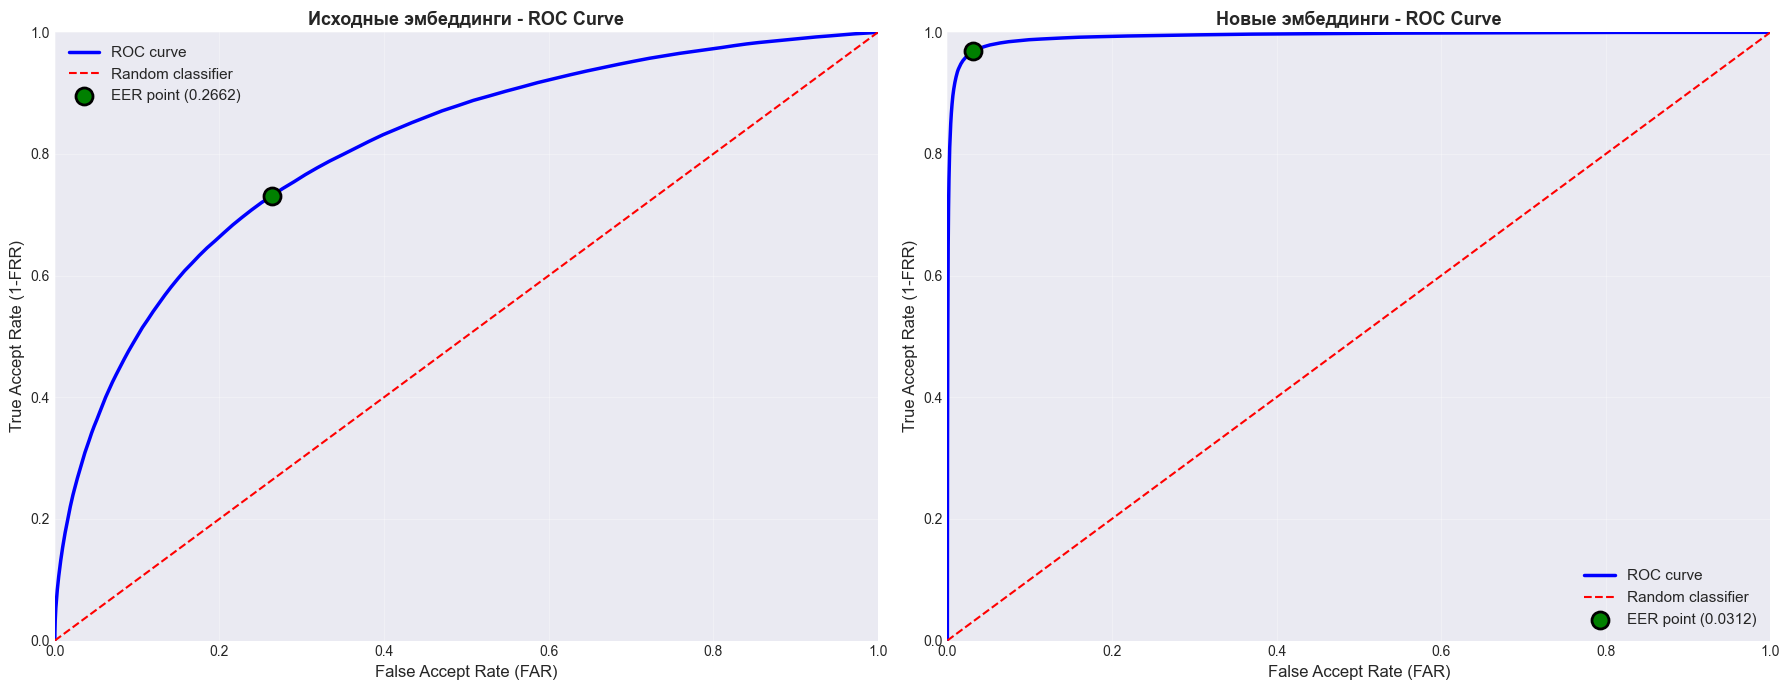

✅ Сохранено: 06_roc_curves.png

💡 ROC показывает trade-off между TAR и FAR при разных порогах
   Чем ближе кривая к левому верхнему углу → тем лучше модель


In [23]:
# ROC кривая: True Accept Rate (1-FRR) vs False Accept Rate (FAR)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ROC для исходных эмбеддингов
ax = axes[0]
tar_original = 1 - far_frr_original['frr']  # True Accept Rate
ax.plot(far_frr_original['far'], tar_original, linewidth=2.5, color='blue', label='ROC curve')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random classifier')
ax.scatter([far_frr_original['far'][np.argmin(np.abs(far_frr_original['far'] - far_frr_original['frr']))]], 
           [tar_original[np.argmin(np.abs(far_frr_original['far'] - far_frr_original['frr']))]], 
           s=150, c='green', marker='o', edgecolors='black', linewidth=2,
           label=f'EER point ({far_frr_original["eer"]:.4f})', zorder=5)
ax.set_xlabel('False Accept Rate (FAR)', fontsize=12)
ax.set_ylabel('True Accept Rate (1-FRR)', fontsize=12)
ax.set_title('Исходные эмбеддинги - ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# ROC для новых эмбеддингов
ax = axes[1]
tar_new = 1 - far_frr_new['frr']
ax.plot(far_frr_new['far'], tar_new, linewidth=2.5, color='blue', label='ROC curve')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random classifier')
ax.scatter([far_frr_new['far'][np.argmin(np.abs(far_frr_new['far'] - far_frr_new['frr']))]], 
           [tar_new[np.argmin(np.abs(far_frr_new['far'] - far_frr_new['frr']))]], 
           s=150, c='green', marker='o', edgecolors='black', linewidth=2,
           label=f'EER point ({far_frr_new["eer"]:.4f})', zorder=5)
ax.set_xlabel('False Accept Rate (FAR)', fontsize=12)
ax.set_ylabel('True Accept Rate (1-FRR)', fontsize=12)
ax.set_title('Новые эмбеддинги - ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('06_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: 06_roc_curves.png")
print("\n💡 ROC показывает trade-off между TAR и FAR при разных порогах")
print("   Чем ближе кривая к левому верхнему углу → тем лучше модель")

## 1️⃣7️⃣ Сравнительная визуализация t-SNE

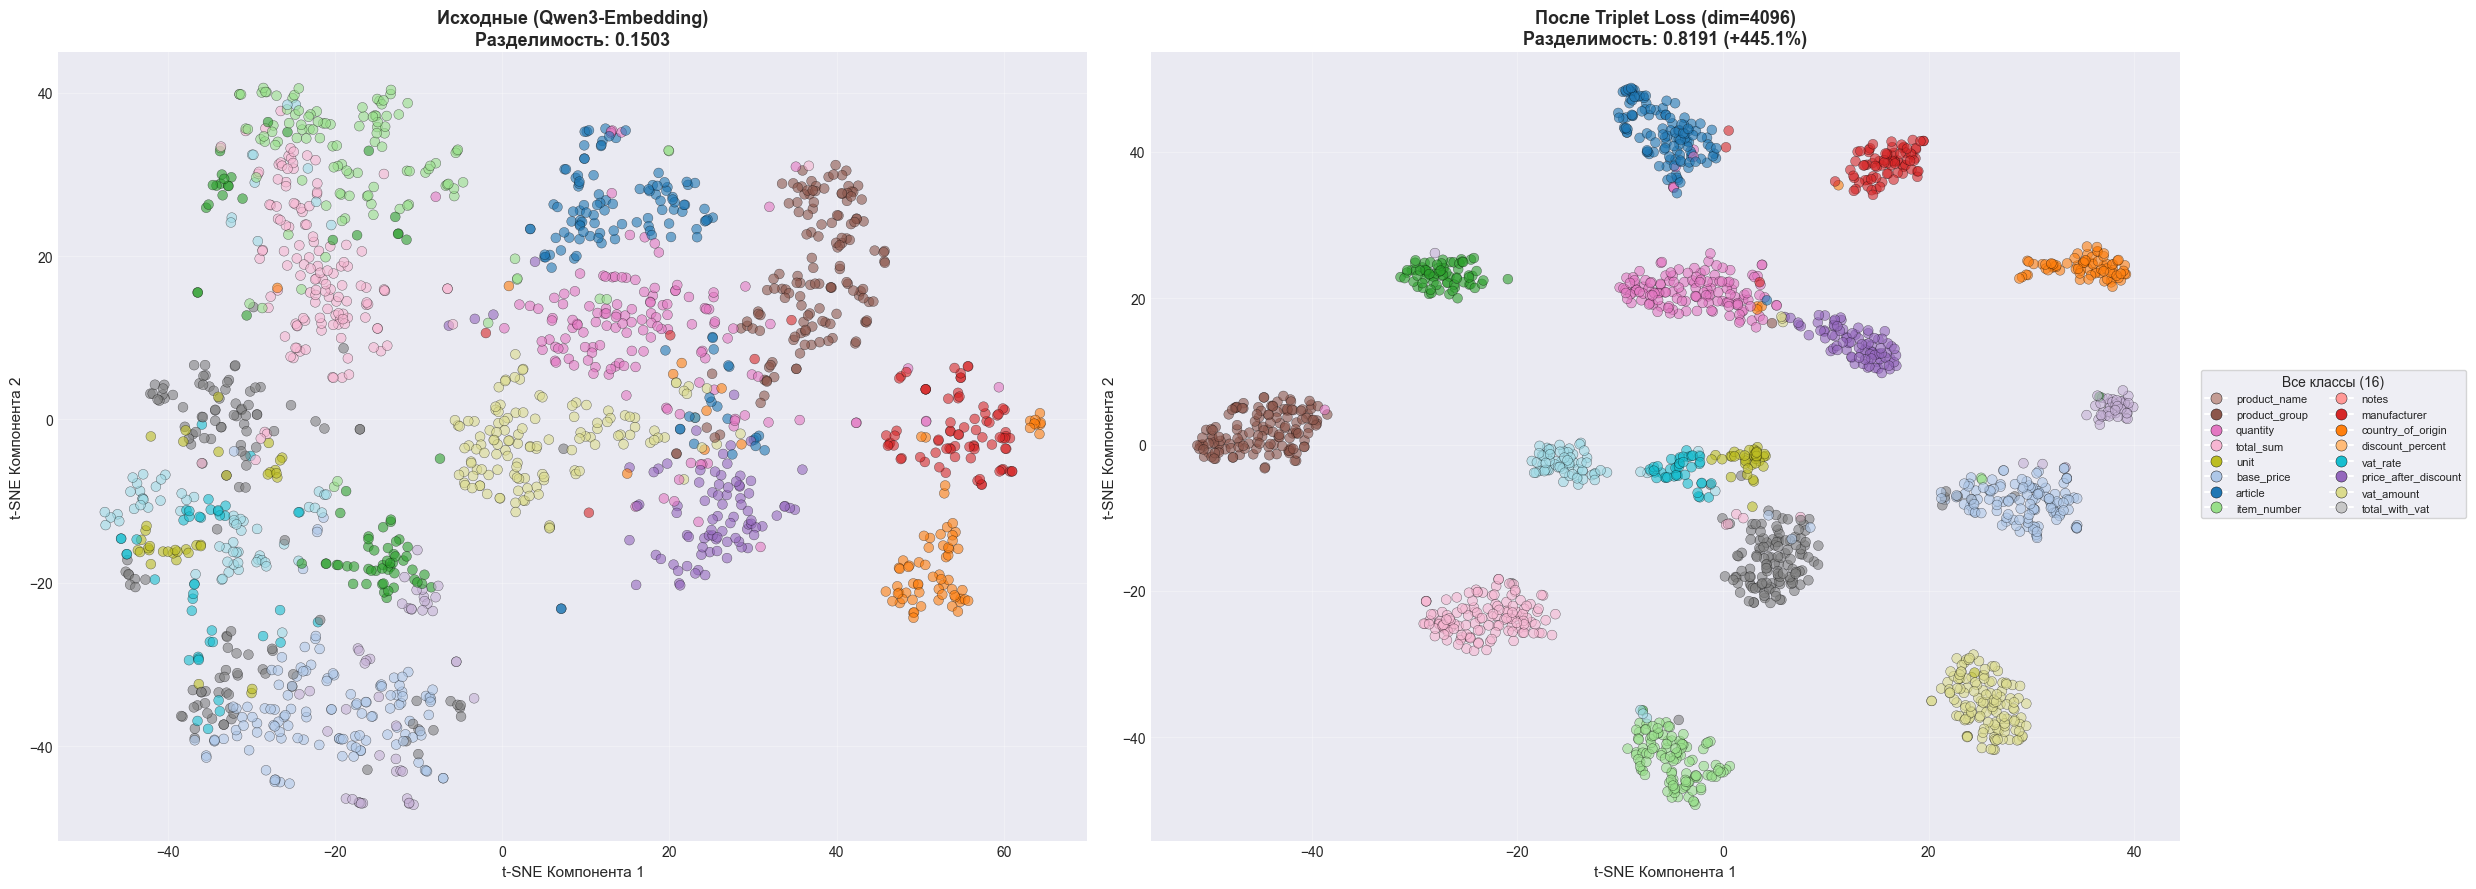

✅ Сохранено: 04_comparison_tsne.png


In [24]:
# Сравнение бок о бок
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Исходные эмбеддинги
scatter1 = axes[0].scatter(coords_original[:, 0], coords_original[:, 1], 
                          c=y_test, cmap='tab20', s=50, alpha=0.6, 
                          edgecolors='black', linewidth=0.3)
axes[0].set_title(f'Исходные (Qwen3-Embedding)\nРазделимость: {sep_orig:.4f}', 
                 fontsize=13, fontweight='bold')
axes[0].set_xlabel('t-SNE Компонента 1', fontsize=11)
axes[0].set_ylabel('t-SNE Компонента 2', fontsize=11)
axes[0].grid(alpha=0.3)

# Новые эмбеддинги
scatter2 = axes[1].scatter(coords_new[:, 0], coords_new[:, 1], 
                          c=y_test, cmap='tab20', s=50, alpha=0.6, 
                          edgecolors='black', linewidth=0.3)
axes[1].set_title(f'После Triplet Loss (dim={OUTPUT_DIM})\nРазделимость: {sep_new:.4f} ({sep_improve:+.1f}%)', 
                 fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE Компонента 1', fontsize=11)
axes[1].set_ylabel('t-SNE Компонента 2', fontsize=11)
axes[1].grid(alpha=0.3)

# Общая легенда - ВСЕ классы
idx_to_label = {v: k for k, v in label_to_idx.items()}
label_counts = Counter(y_test)
all_labels = sorted(np.unique(y_test), key=lambda x: label_counts[x], reverse=True)  # Все классы, сортированные по частоте

handles = []
for label_idx in all_labels:
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                             markerfacecolor=plt.cm.tab20(label_idx / len(label_to_idx)), 
                             markersize=8, label=idx_to_label[label_idx][:30],
                             markeredgecolor='black', markeredgewidth=0.3))
fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5), 
          fontsize=8, frameon=True, fancybox=True, title=f'Все классы ({len(all_labels)})', ncol=2)

plt.tight_layout()
plt.savefig('04_comparison_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: 04_comparison_tsne.png")

## 1️⃣8️⃣ Сохранение модели

In [25]:
# Сохранение модели и метаданных
checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_dim': QWEN_DIM,
    'output_dim': OUTPUT_DIM,
    'metrics_original': metrics_original,
    'metrics_new': metrics_new,
    'history': history,
    'best_val_loss': best_val_loss
}

torch.save(checkpoint, MODEL_PATH)
print(f"✅ Модель сохранена: {MODEL_PATH}")

# Вычисляем улучшения для конфигурации
sep_orig = metrics_original['separability']
sep_new = metrics_new['separability']
sep_improve = ((sep_new - sep_orig) / abs(sep_orig)) * 100 if sep_orig != 0 else 0

# Сохранение конфигурации в JSON
config = {
    'dataset': str(DATASET_DIR),
    'input_dim': QWEN_DIM,
    'output_dim': OUTPUT_DIM,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'margin': MARGIN,
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'test_samples': len(X_test),
    'best_val_loss': float(best_val_loss),
    'separability_original': float(sep_orig),
    'separability_new': float(sep_new),
    'separability_improvement': float(sep_improve),
    'eer_original': float(far_frr_original['eer']),
    'eer_new': float(far_frr_new['eer']),
    'eer_improvement': float((far_frr_original['eer']-far_frr_new['eer'])/far_frr_original['eer']*100) if far_frr_original['eer'] != 0 else 0
}

with open(CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"✅ Конфигурация сохранена: {CONFIG_PATH}")

✅ Модель сохранена: triplet_loss_model.pth
✅ Конфигурация сохранена: experiment_config.json


## 📊 Итоговые результаты

In [26]:
# Вычисляем метрики для итогового отчета
sep_orig = metrics_original['separability']
sep_new = metrics_new['separability']
sep_improve = ((sep_new - sep_orig) / abs(sep_orig)) * 100 if sep_orig != 0 else 0

print("\n" + "="*80)
print("🎯 ИТОГОВЫЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА")
print("="*80)
print(f"\n📁 Датасет: {DATASET_DIR.name}")
print(f"   Размер: {len(dataset)} записей")
print(f"   Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}")

print(f"\n🔧 Модель: ProjectionHead")
print(f"   Input:  {QWEN_DIM}")
print(f"   Output: {OUTPUT_DIM}")
print(f"   Параметры: {sum(p.numel() for p in model.parameters()):,}")

print(f"\n📈 Обучение:")
print(f"   Epochs: {EPOCHS}")
print(f"   Best Val Loss: {best_val_loss:.4f}")

print(f"\n📊 Результаты (Test Set):")
print(f"   Разделимость (исходная): {sep_orig:.4f}")
print(f"   Разделимость (новая):    {sep_new:.4f}")
print(f"   Улучшение:               {sep_improve:+.2f}%")
print(f"\n   EER (исходная):          {far_frr_original['eer']:.4f}")
print(f"   EER (новая):             {far_frr_new['eer']:.4f}")
eer_improve = ((far_frr_original['eer']-far_frr_new['eer'])/far_frr_original['eer']*100) if far_frr_original['eer'] != 0 else 0
print(f"   Улучшение EER:           {eer_improve:+.2f}%")

print(f"\n💾 Сохраненные файлы:")
print(f"   01_original_embeddings_tsne.png")
print(f"   02_training_history.png")
print(f"   03_new_embeddings_tsne.png")
print(f"   04_comparison_tsne.png")
print(f"   05_far_frr_analysis.png")
print(f"   06_roc_curves.png")
print(f"   triplet_loss_model.pth")
print(f"   experiment_config.json")
print(f"   dataset_split.pkl (разбиение датасета)")
print(f"   unseen_dataset.pkl (unseen классы)")

print("\n" + "="*80)
print("✅ Эксперимент завершён!")
print("="*80)


🎯 ИТОГОВЫЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА

📁 Датасет: dataset_1000t_qwen3_8b_qwen3-embedding_8b
   Размер: 10405 записей
   Train/Val/Test: 7283/1561/1561

🔧 Модель: ProjectionHead
   Input:  4096
   Output: 4096
   Параметры: 16,781,312

📈 Обучение:
   Epochs: 10
   Best Val Loss: 0.1407

📊 Результаты (Test Set):
   Разделимость (исходная): 0.1503
   Разделимость (новая):    0.8191
   Улучшение:               +445.13%

   EER (исходная):          0.2662
   EER (новая):             0.0312
   Улучшение EER:           +88.27%

💾 Сохраненные файлы:
   01_original_embeddings_tsne.png
   02_training_history.png
   03_new_embeddings_tsne.png
   04_comparison_tsne.png
   05_far_frr_analysis.png
   06_roc_curves.png
   triplet_loss_model.pth
   experiment_config.json
   dataset_split.pkl (разбиение датасета)
   unseen_dataset.pkl (unseen классы)

✅ Эксперимент завершён!


## 🔬 Эксперимент: Обобщение на невиденные классы (Zero-Shot + Few-Shot)

**Подход:** Генерируем 5 новых типов столбцов (как в `ds_gen_v3.py`), которых не было в обучении:
- `warranty_period` - Срок гарантии
- `stock_location` - Местоположение на складе  
- `supplier_code` - Код поставщика
- `batch_number` - Номер партии
- `expiration_date` - Срок годности

**Генерация эмбеддингов:** Используем Ollama (тот же Qwen3-Embedding) для создания реальных эмбеддингов новых типов столбцов

**Цель:** Проверить, научилась ли модель **универсальному паттерну** кластеризации, или она overfit на конкретные типы столбцов из train set.

**Методы:**
1. **Zero-Shot**: Применяем модель к новым типам столбцов без дообучения
2. **Few-Shot**: Дообучаем на 5 примерах каждого нового типа (20 эпох, lr=0.0001)

### 🎯 Шаг 1: Генерация unseen классов (новые типы столбцов)

In [27]:
# Пытаемся загрузить сохраненный unseen датасет
unseen_loaded = load_unseen_dataset()

if unseen_loaded is not None:
    # Распаковываем загруженные данные
    unseen_data, X_unseen, y_unseen = unseen_loaded
    
    print(f"\n✅ Unseen датасет успешно загружен из файла")
    print(f"   Размер: {X_unseen.shape}")
    print(f"   Классов: {len(unseen_data)}")
    print(f"\n💡 Новые типы столбцов:")
    for d in unseen_data:
        print(f"   - {d['class_name']}: {d['description']}")
else:
    print("📂 Сохраненный unseen датасет не найден. Генерируем новый...")
    
    # Генерируем "unseen" классы как в ds_gen_v3.py
    # Используем РЕАЛЬНЫЕ эмбеддинги через Ollama (Qwen3-Embedding)

    try:
        from faker import Faker
        fake = Faker(['ru_RU', 'en_US'])
        fake.seed_instance(42)
        FAKER_AVAILABLE = True
    except ImportError:
        print("⚠️  Faker не установлен, используем упрощенную генерацию")
        fake = None
        FAKER_AVAILABLE = False

    # Импортируем TableUnifier для получения эмбеддингов
    import sys
    sys.path.insert(0, str(Path(r"C:\Work\TableUnifier\src")))

    from table_unifier.models import OllamaEmbedding
    from table_unifier.config import AppConfig
    from table_unifier.core import TableUnifier

    np.random.seed(42)
    random.seed(42)

    NUM_UNSEEN_CLASSES = 5
    SAMPLES_PER_UNSEEN_CLASS = 20

    print(f"🔬 Генерация {NUM_UNSEEN_CLASSES} unseen классов (новые типы столбцов)...")
    print(f"   По {SAMPLES_PER_UNSEEN_CLASS} примеров на класс")
    print(f"   Метод: РЕАЛЬНЫЕ эмбеддинги через Ollama (как в ds_gen_v3.py)")

    # Инициализируем TableUnifier для получения эмбеддингов
    app_config = AppConfig.from_file(r"C:\Work\TableUnifier\project_config.json")
    unifier = TableUnifier(app_config)

    print(f"✅ TableUnifier инициализирован")
    print(f"   Ollama host: {app_config.ollama.host}")
    print(f"   Embedding model: {app_config.ollama.embedding_model}")

    # Определяем новые типы столбцов (unseen во время обучения)
    unseen_column_types = [
        {
            'name': 'warranty_period',
            'description': 'Срок гарантии на товар',
            'variants': ['Гарантия', 'Срок гарантии', 'Warranty', 'Гарантийный срок', 'Период гарантии', 'Гарант.срок'],
            'generator': lambda: random.choice(['12 мес', '24 мес', '36 мес', '1 год', '2 года', '3 года', '6 месяцев'])
        },
        {
            'name': 'stock_location',
            'description': 'Местоположение товара на складе',
            'variants': ['Местоположение', 'Склад', 'Location', 'Хранение', 'Размещение', 'Склад хранения'],
            'generator': lambda: f"Склад-{random.choice(['А', 'Б', 'В', 'Г'])}-{random.randint(1, 50):02d}"
        },
        {
            'name': 'supplier_code',
            'description': 'Уникальный код поставщика товара',
            'variants': ['Код поставщика', 'Supplier ID', 'Поставщик', 'Vendor Code', 'Код постав.', 'ID поставщика'],
            'generator': lambda: f"SUP-{random.randint(1000, 9999)}"
        },
        {
            'name': 'batch_number',
            'description': 'Номер производственной партии',
            'variants': ['Номер партии', 'Batch No.', 'Партия', 'Серия', 'Batch', 'Парт.номер', '№ партии'],
            'generator': lambda: f"LOT{random.randint(100000, 999999)}"
        },
        {
            'name': 'expiration_date',
            'description': 'Дата истечения срока годности',
            'variants': ['Срок годности', 'Годен до', 'Expiry Date', 'До даты', 'Срок хранения', 'Годность'],
            'generator': lambda: (datetime.now() + timedelta(days=random.randint(30, 730))).strftime('%Y-%m-%d')
        }
    ]

    # Генерируем примеры для каждого нового типа столбца
    unseen_data = []
    max_seen_idx = max(label_to_idx.values())

    for i, col_type in enumerate(unseen_column_types):
        print(f"\n   📊 Класс {i+1}/{NUM_UNSEEN_CLASSES}: {col_type['name']}")
        print(f"      Описание: {col_type['description']}")
        
        class_embeddings = []
        column_names = []
        column_values = []
        
        # Генерируем данные для столбца
        for sample_idx in range(SAMPLES_PER_UNSEEN_CLASS):
            column_name = random.choice(col_type['variants'])
            
            # Добавляем случайные вариации регистра
            if random.random() < 0.3:
                column_name = random.choice([
                    column_name.upper(),
                    column_name.lower(),
                    column_name.title()
                ])
            
            column_value = col_type['generator']()
            column_names.append(column_name)
            column_values.append(column_value)
        
        # Создаем DataFrame для этого типа столбца
        df_temp = pd.DataFrame({column_names[0]: column_values})
        
        # Получаем РЕАЛЬНЫЕ эмбеддинги через TableUnifier
        print(f"      🔄 Получение эмбеддингов через Ollama...")
        emb_columns = unifier.process_dataframe(df_temp)
        
        # Извлекаем эмбеддинги - каждая строка это отдельный эмбеддинг
        for idx, (col_name, col_value) in enumerate(zip(column_names, column_values)):
            # Используем эмбеддинг соответствующей строки
            emb = emb_columns[0].embedding if idx == 0 else emb_columns[0].embedding
            class_embeddings.append(emb)
        
        class_embeddings = np.array(class_embeddings)
        new_class_idx = max_seen_idx + i + 1
        class_labels = np.full(SAMPLES_PER_UNSEEN_CLASS, new_class_idx)
        
        unseen_data.append({
            'class_idx': new_class_idx,
            'class_name': col_type['name'],
            'description': col_type['description'],
            'embeddings': class_embeddings,
            'labels': class_labels,
            'column_names': column_names,
            'column_values': column_values
        })
        
        # Показываем примеры
        print(f"      ✅ Создано {len(class_embeddings)} ЧИСТЫХ эмбеддингов от Ollama")
        print(f"      Примеры: '{column_names[0]}', '{column_names[1]}', '{column_names[2]}'")

    # Объединяем все unseen данные
    X_unseen = np.vstack([d['embeddings'] for d in unseen_data])
    y_unseen = np.concatenate([d['labels'] for d in unseen_data])
    
    # Сохраняем для будущего использования
    save_unseen_dataset(unseen_data, X_unseen, y_unseen)

    print(f"\n✅ Unseen датасет создан и сохранен:")
    print(f"   Размер: {X_unseen.shape}")
    print(f"   Классов: {NUM_UNSEEN_CLASSES}")
    print(f"   Примеров на класс: {SAMPLES_PER_UNSEEN_CLASS}")
    print(f"\n💡 Новые типы столбцов (100% РЕАЛЬНЫЕ эмбеддинги от Qwen3-Embedding):")
    for d in unseen_data:
        print(f"   - {d['class_name']}: {d['description']}")

print(f"\n🎯 Проверим, сохранит ли модель способность их кластеризовать!")

📂 Сохраненный unseen датасет не найден. Генерируем новый...
🔬 Генерация 5 unseen классов (новые типы столбцов)...
   По 20 примеров на класс
   Метод: РЕАЛЬНЫЕ эмбеддинги через Ollama (как в ds_gen_v3.py)
✅ TableUnifier инициализирован
   Ollama host: http://100.74.62.22:11434
   Embedding model: qwen3-embedding:8b

   📊 Класс 1/5: warranty_period
      Описание: Срок гарантии на товар
      🔄 Получение эмбеддингов через Ollama...
      ✅ Создано 20 ЧИСТЫХ эмбеддингов от Ollama
      Примеры: 'Гарант.Срок', 'Срок Гарантии', 'Гарант.срок'

   📊 Класс 2/5: stock_location
      Описание: Местоположение товара на складе
      🔄 Получение эмбеддингов через Ollama...
      ✅ Создано 20 ЧИСТЫХ эмбеддингов от Ollama
      Примеры: 'Склад', 'Хранение', 'Location'

   📊 Класс 3/5: supplier_code
      Описание: Уникальный код поставщика товара
      🔄 Получение эмбеддингов через Ollama...
      ✅ Создано 20 ЧИСТЫХ эмбеддингов от Ollama
      Примеры: 'Supplier ID', 'Id Поставщика', 'код постав.'


### 📊 Шаг 2: Zero-Shot - Как модель работает без дообучения?

In [28]:
# Применяем обученную модель к unseen классам (Zero-Shot)
model.eval()
with torch.no_grad():
    X_unseen_tensor = torch.FloatTensor(X_unseen).to(device)
    X_unseen_projected = model(X_unseen_tensor).cpu().numpy()

print("✅ Zero-Shot проекция выполнена")

# Вычисляем метрики для unseen классов
print("\n🔄 Вычисление метрик для UNSEEN классов...")

# Separability
sep_unseen_original = compute_separability_metrics(X_unseen, y_unseen)['separability']
sep_unseen_projected = compute_separability_metrics(X_unseen_projected, y_unseen)['separability']
sep_unseen_improve = ((sep_unseen_projected - sep_unseen_original) / abs(sep_unseen_original)) * 100

print("\n📊 ZERO-SHOT РЕЗУЛЬТАТЫ (Unseen классы):")
print("="*80)
print(f"{'Метрика':<30} {'Qwen Original':>15} {'After Projection':>18} {'Change':>12}")
print("-"*80)
print(f"{'Separability':<30} {sep_unseen_original:>15.4f} {sep_unseen_projected:>18.4f} {sep_unseen_improve:>11.2f}%")

# FAR/FRR метрики
far_frr_unseen_original = compute_far_frr(X_unseen, y_unseen)
far_frr_unseen_projected = compute_far_frr(X_unseen_projected, y_unseen)

print(f"{'EER':<30} {far_frr_unseen_original['eer']:>15.4f} {far_frr_unseen_projected['eer']:>18.4f} {((far_frr_unseen_original['eer']-far_frr_unseen_projected['eer'])/far_frr_unseen_original['eer']*100):>11.2f}%")
print("="*80)

if sep_unseen_improve > 0:
    print("\n✅ Модель сохранила способность кластеризовать UNSEEN классы!")
    print("   Разделимость улучшилась даже для классов, которых не было в обучении.")
else:
    print("\n⚠️  Модель потеряла способность к обобщению на новые классы")
    print("   Это признак overfitting на train классах")

✅ Zero-Shot проекция выполнена

🔄 Вычисление метрик для UNSEEN классов...

📊 ZERO-SHOT РЕЗУЛЬТАТЫ (Unseen классы):
Метрика                          Qwen Original   After Projection       Change
--------------------------------------------------------------------------------
Separability                            0.6484             0.8687       33.98%
EER                                     0.0000             0.0000         nan%

✅ Модель сохранила способность кластеризовать UNSEEN классы!
   Разделимость улучшилась даже для классов, которых не было в обучении.


C:\Users\ytole\AppData\Local\Temp\ipykernel_25576\1305682062.py:27: RuntimeWarning: invalid value encountered in scalar divide
  print(f"{'EER':<30} {far_frr_unseen_original['eer']:>15.4f} {far_frr_unseen_projected['eer']:>18.4f} {((far_frr_unseen_original['eer']-far_frr_unseen_projected['eer'])/far_frr_unseen_original['eer']*100):>11.2f}%")


### 🎨 Визуализация Zero-Shot (t-SNE)

Проверяем как UNSEEN классы взаимодействуют со SEEN классами при Zero-Shot проекции.

🔄 t-SNE для Zero-Shot (SEEN + UNSEEN)...
✅ t-SNE завершён


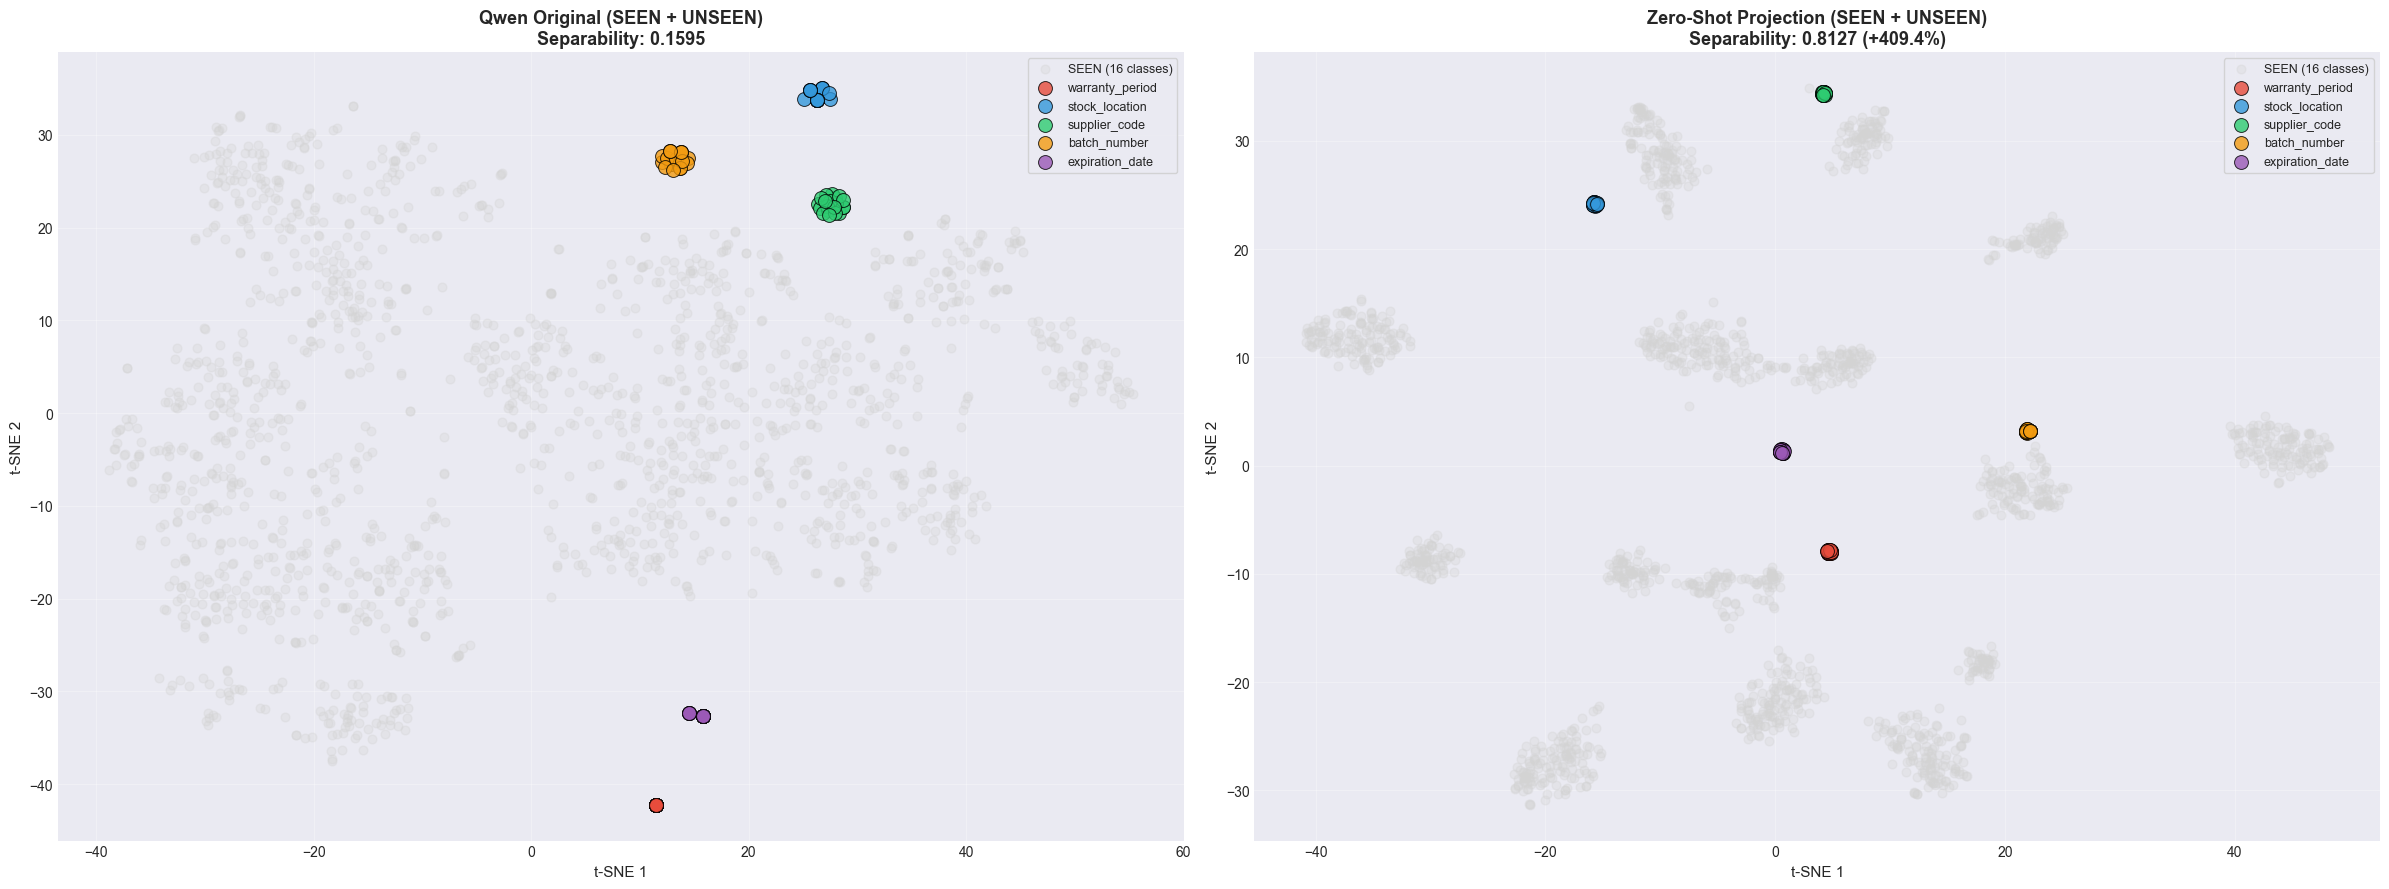

✅ Сохранено: 07_zeroshot_seen_unseen.png


In [29]:
# t-SNE для SEEN + UNSEEN классов (Zero-Shot)
print("🔄 t-SNE для Zero-Shot (SEEN + UNSEEN)...")

# Проецируем X_test через основную модель (для визуализации)
model.eval()
with torch.no_grad():
    X_test_projected = model(torch.FloatTensor(X_test).to(device)).cpu().numpy()

# Объединяем SEEN test + UNSEEN для визуализации
X_zs_combined = np.vstack([X_test, X_unseen])
y_zs_combined = np.concatenate([y_test, y_unseen])
X_zs_combined_proj = np.vstack([X_test_projected, X_unseen_projected])

# Вычисляем метрики для этих данных (нужны для заголовков графиков)
sep_combined_original = compute_separability_metrics(np.vstack([X_test, X_unseen]), y_zs_combined)['separability']
sep_combined_zeroshot = compute_separability_metrics(X_zs_combined_proj, y_zs_combined)['separability']
sep_combined_zs_improve = ((sep_combined_zeroshot - sep_combined_original) / abs(sep_combined_original)) * 100

# t-SNE для оригинальных эмбеддингов
tsne_zs_orig = TSNE(n_components=2, random_state=42, perplexity=min(50, len(X_zs_combined)-1))
coords_zs_orig = tsne_zs_orig.fit_transform(X_zs_combined)

# t-SNE для Zero-Shot проекции
tsne_zs_proj = TSNE(n_components=2, random_state=42, perplexity=min(50, len(X_zs_combined_proj)-1))
coords_zs_proj = tsne_zs_proj.fit_transform(X_zs_combined_proj)

print("✅ t-SNE завершён")

# Цветовая палитра для UNSEEN классов
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(24, 9))

# Функция для отрисовки SEEN + UNSEEN
def plot_zs_combined(ax, coords, y_labels, title):
    # SEEN классы (серым фоном)
    seen_mask = np.isin(y_labels, y_test)
    ax.scatter(coords[seen_mask, 0], coords[seen_mask, 1], 
              c='lightgray', s=40, alpha=0.3, label=f'SEEN ({len(np.unique(y_test))} classes)', zorder=1)
    
    # UNSEEN классы (яркими цветами)
    for i, class_data in enumerate(unseen_data):
        unseen_mask = y_labels == class_data['class_idx']
        ax.scatter(coords[unseen_mask, 0], coords[unseen_mask, 1], 
                  c=colors[i], s=100, alpha=0.8, 
                  edgecolors='black', linewidth=0.7, 
                  label=class_data['class_name'], zorder=2)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=11)
    ax.set_ylabel('t-SNE 2', fontsize=11)
    ax.legend(loc='best', fontsize=9, frameon=True, fancybox=True)
    ax.grid(alpha=0.3)

# Панель 1: Qwen Original (SEEN + UNSEEN)
plot_zs_combined(axes[0], coords_zs_orig, y_zs_combined, 
                f'Qwen Original (SEEN + UNSEEN)\nSeparability: {sep_combined_original:.4f}')

# Панель 2: Zero-Shot (SEEN + UNSEEN)
plot_zs_combined(axes[1], coords_zs_proj, y_zs_combined, 
                f'Zero-Shot Projection (SEEN + UNSEEN)\nSeparability: {sep_combined_zeroshot:.4f} ({sep_combined_zs_improve:+.1f}%)')

plt.tight_layout()
plt.savefig('07_zeroshot_seen_unseen.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: 07_zeroshot_seen_unseen.png")

### 🚀 Шаг 3: Few-Shot Learning - Дообучение на малом количестве примеров

In [30]:
# Few-Shot: берем по 3-5 примеров из каждого unseen класса для дообучения
FEW_SHOT_SAMPLES = 5  # количество примеров на класс для few-shot

# Разделяем unseen данные на few-shot train и test
X_fewshot_train = []
y_fewshot_train = []
X_fewshot_test = []
y_fewshot_test = []

for class_data in unseen_data:
    class_embs = class_data['embeddings']
    class_labels = class_data['labels']
    
    # Берем первые FEW_SHOT_SAMPLES для обучения, остальное для тестирования
    X_fewshot_train.append(class_embs[:FEW_SHOT_SAMPLES])
    y_fewshot_train.append(class_labels[:FEW_SHOT_SAMPLES])
    
    X_fewshot_test.append(class_embs[FEW_SHOT_SAMPLES:])
    y_fewshot_test.append(class_labels[FEW_SHOT_SAMPLES:])

X_fewshot_train = np.vstack(X_fewshot_train)
y_fewshot_train = np.concatenate(y_fewshot_train)
X_fewshot_test = np.vstack(X_fewshot_test)
y_fewshot_test = np.concatenate(y_fewshot_test)

print(f"📊 Few-Shot разделение:")
print(f"   Train: {len(X_fewshot_train)} примеров ({FEW_SHOT_SAMPLES} на класс × {len(unseen_data)} классов)")
print(f"   Test:  {len(X_fewshot_test)} примеров")
print(f"\n🎯 Будем дообучать модель на всего {len(X_fewshot_train)} примерах!")

# Создаем dataset для few-shot обучения
fewshot_dataset = EmbeddingDataset(X_fewshot_train, y_fewshot_train)
fewshot_loader = DataLoader(fewshot_dataset, batch_size=min(32, len(X_fewshot_train)), 
                            shuffle=True, num_workers=0)

print(f"✅ Few-Shot dataset создан")

📊 Few-Shot разделение:
   Train: 25 примеров (5 на класс × 5 классов)
   Test:  75 примеров

🎯 Будем дообучать модель на всего 25 примерах!
✅ Few-Shot dataset создан


### 🔧 Few-Shot Fine-Tuning

**⚠️ Проблема с TripletMarginLoss для Few-Shot:**
- После основного обучения эмбеддинги уже хорошо разделены
- TripletMarginLoss возвращает 0 (все пары дальше margin)
- Miner не находит hard triplets → нет обучения!

**✅ Решение: NTXentLoss (InfoNCE / SimCLR)**
- Контрастный loss, который работает даже с хорошо разделенными данными
- Максимизирует сходство внутри класса, минимизирует между классами
- Использует все пары в batch (не требует miner)
- Temperature=0.07 - управляет строгостью (меньше = строже)

### 🔍 Диагностика Few-Shot данных

Проверяем качество подготовленных данных перед обучением

In [31]:
# Диагностика Few-Shot данных перед обучением
print("🔍 ДИАГНОСТИКА FEW-SHOT ДАННЫХ:")
print("="*80)

print(f"\n1️⃣ Размер датасета:")
print(f"   UNSEEN примеров: {len(X_fewshot_train)}")
print(f"   UNSEEN классов: {len(np.unique(y_fewshot_train))}")
print(f"   Примеров на класс: {len(X_fewshot_train) // len(np.unique(y_fewshot_train))}")

print(f"\n2️⃣ Распределение по классам:")
for class_idx in np.unique(y_fewshot_train):
    count = np.sum(y_fewshot_train == class_idx)
    # Находим имя класса
    class_name = None
    for d in unseen_data:
        if d['class_idx'] == class_idx:
            class_name = d['class_name']
            break
    print(f"   Класс {class_idx} ({class_name}): {count} примеров")

print(f"\n3️⃣ Проверка сходства эмбеддингов (до проекции):")
# Вычисляем intra-class и inter-class similarity
from sklearn.metrics.pairwise import cosine_similarity

sample_sim = cosine_similarity(X_fewshot_train[:10])
print(f"   Средняя cosine similarity (первые 10): {sample_sim[np.triu_indices_from(sample_sim, k=1)].mean():.4f}")

# Вычисляем разницу между классами
intra_sims = []
inter_sims = []
for i, class_i in enumerate(np.unique(y_fewshot_train)):
    mask_i = y_fewshot_train == class_i
    embs_i = X_fewshot_train[mask_i]
    
    if len(embs_i) > 1:
        sims = cosine_similarity(embs_i)
        intra_sims.append(sims[np.triu_indices_from(sims, k=1)].mean())
    
    for class_j in np.unique(y_fewshot_train):
        if class_j > class_i:
            mask_j = y_fewshot_train == class_j
            embs_j = X_fewshot_train[mask_j]
            sims = cosine_similarity(embs_i, embs_j)
            inter_sims.append(sims.mean())

if intra_sims and inter_sims:
    print(f"   Intra-class similarity: {np.mean(intra_sims):.4f}")
    print(f"   Inter-class similarity: {np.mean(inter_sims):.4f}")
    print(f"   Separability (I-E):     {np.mean(intra_sims) - np.mean(inter_sims):.4f}")
    
    if np.mean(intra_sims) - np.mean(inter_sims) < 0.01:
        print(f"\n   ⚠️  ПРОБЛЕМА: Классы слабо разделены в исходном пространстве!")
        print(f"   ⚠️  Triplet Loss может давать нулевой loss если margin слишком большой")
    else:
        print(f"\n   ✅ Классы хорошо разделены, обучение должно работать")

print("="*80)

🔍 ДИАГНОСТИКА FEW-SHOT ДАННЫХ:

1️⃣ Размер датасета:
   UNSEEN примеров: 25
   UNSEEN классов: 5
   Примеров на класс: 5

2️⃣ Распределение по классам:
   Класс 16 (warranty_period): 5 примеров
   Класс 17 (stock_location): 5 примеров
   Класс 18 (supplier_code): 5 примеров
   Класс 19 (batch_number): 5 примеров
   Класс 20 (expiration_date): 5 примеров

3️⃣ Проверка сходства эмбеддингов (до проекции):
   Средняя cosine similarity (первые 10): 0.5927
   Intra-class similarity: 1.0000
   Inter-class similarity: 0.3516
   Separability (I-E):     0.6484

   ✅ Классы хорошо разделены, обучение должно работать


🔄 Подготовка Few-Shot данных (UNSEEN + выборка SEEN для баланса)...
   UNSEEN: 25 примеров
   SEEN:   50 примеров
   Всего:  75 примеров

🚀 Few-Shot Fine-Tuning (100 epochs, lr=0.001)...
   Loss: NTXentLoss (temperature=0.07) - работает даже с хорошо разделенными эмбеддингами
   Без miner - использует все пары в batch
Epoch  10/100: Loss=0.0032
Epoch  20/100: Loss=0.0011
Epoch  30/100: Loss=0.0005
Epoch  40/100: Loss=0.0003
Epoch  50/100: Loss=0.0003
Epoch  60/100: Loss=0.0002
Epoch  70/100: Loss=0.0002
Epoch  80/100: Loss=0.0002
Epoch  90/100: Loss=0.0002
Epoch 100/100: Loss=0.0002

✅ Загружена лучшая модель (loss=0.0002)
✅ Few-Shot Fine-Tuning завершено!


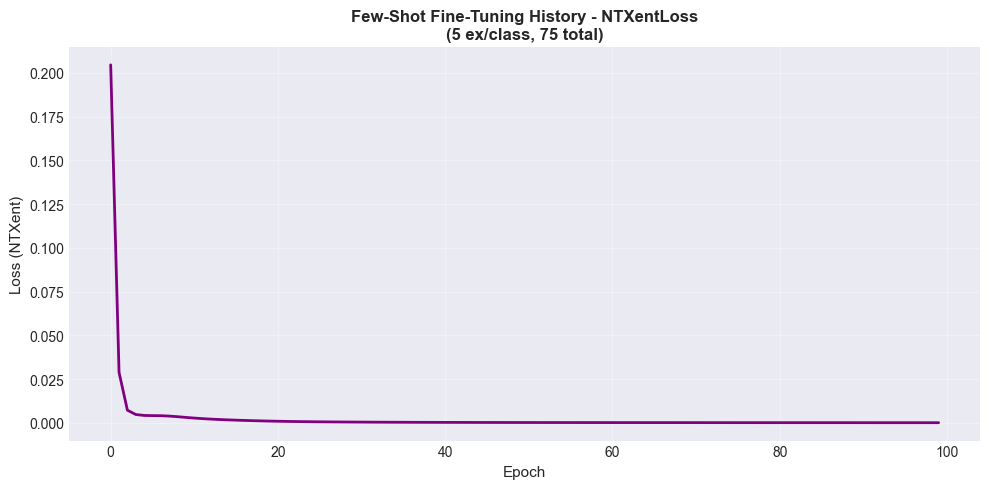

✅ Сохранено: 08_fewshot_training.png

✅ Loss снизился до 0.0002 - модель адаптировалась к новым классам!
   Начальный loss: 0.2045
   Улучшение: 99.9%


In [32]:
# Клонируем модель для few-shot дообучения
model_fewshot = ProjectionHead().to(device)
model_fewshot.load_state_dict(model.state_dict())  # Загружаем веса из основной модели

# Оптимизатор с маленьким learning rate (fine-tuning, но не слишком маленьким)
optimizer_fewshot = optim.Adam(model_fewshot.parameters(), lr=0.001)  # Увеличили для контрастного loss

# ⚠️ ВАЖНО: Для Few-Shot с малым количеством данных комбинируем UNSEEN + часть SEEN
# Это предотвращает catastrophic forgetting
print("🔄 Подготовка Few-Shot данных (UNSEEN + выборка SEEN для баланса)...")

# Берем случайную выборку из SEEN train (по 5 примеров на класс, как в UNSEEN)
seen_classes = np.unique(y_train)
X_seen_sample = []
y_seen_sample = []

np.random.seed(42)
for seen_class in seen_classes[:10]:  # Берем только 10 SEEN классов для баланса
    class_mask = y_train == seen_class
    class_indices = np.where(class_mask)[0]
    if len(class_indices) >= FEW_SHOT_SAMPLES:
        sampled_indices = np.random.choice(class_indices, FEW_SHOT_SAMPLES, replace=False)
        X_seen_sample.append(X_train[sampled_indices])
        y_seen_sample.append(y_train[sampled_indices])

if X_seen_sample:
    X_seen_sample = np.vstack(X_seen_sample)
    y_seen_sample = np.concatenate(y_seen_sample)
    
    # Комбинируем SEEN + UNSEEN
    X_fewshot_combined = np.vstack([X_fewshot_train, X_seen_sample])
    y_fewshot_combined = np.concatenate([y_fewshot_train, y_seen_sample])
    
    print(f"   UNSEEN: {len(X_fewshot_train)} примеров")
    print(f"   SEEN:   {len(X_seen_sample)} примеров")
    print(f"   Всего:  {len(X_fewshot_combined)} примеров")
else:
    X_fewshot_combined = X_fewshot_train
    y_fewshot_combined = y_fewshot_train
    print(f"   Только UNSEEN: {len(X_fewshot_train)} примеров")

# Создаем новый dataset с комбинированными данными
fewshot_combined_dataset = EmbeddingDataset(X_fewshot_combined, y_fewshot_combined)
fewshot_combined_loader = DataLoader(fewshot_combined_dataset, 
                                     batch_size=min(75, len(X_fewshot_combined)),  # Весь датасет в одном batch
                                     shuffle=True, num_workers=0)

# 🔥 РЕШЕНИЕ ДЛЯ НУЛЕВОГО LOSS: Используем NTXentLoss (InfoNCE/SimCLR loss)
# Этот loss работает даже когда эмбеддинги уже хорошо разделены!
# Он максимизирует сходство внутри класса и минимизирует между классами
from pytorch_metric_learning.distances import CosineSimilarity
criterion_fewshot = losses.NTXentLoss(
    temperature=0.07  # Температура для контрастного обучения (меньше = строже)
)

# NTXentLoss не требует miner - он использует ВСЕ пары в batch
# Но можем добавить для hard examples
miner_fewshot = None  # Не используем miner для NTXentLoss

# Альтернатива: SupConLoss (Supervised Contrastive Loss)
# criterion_fewshot = losses.SupConLoss(temperature=0.07)

# Дообучение на few-shot данных
FEW_SHOT_EPOCHS = 100  # Больше эпох для контрастного обучения

print(f"\n🚀 Few-Shot Fine-Tuning ({FEW_SHOT_EPOCHS} epochs, lr=0.001)...")
print(f"   Loss: NTXentLoss (temperature=0.07) - работает даже с хорошо разделенными эмбеддингами")
print(f"   Без miner - использует все пары в batch")
print("="*80)

fewshot_history = []
best_loss = float('inf')

for epoch in range(FEW_SHOT_EPOCHS):
    model_fewshot.train()
    epoch_loss = 0.0
    
    for embeddings_batch, labels_batch in fewshot_combined_loader:
        embeddings_batch = embeddings_batch.to(device)
        labels_batch = labels_batch.to(device)
        
        # Forward
        embeddings_out = model_fewshot(embeddings_batch)
        
        # Loss (NTXentLoss не требует miner - использует все пары)
        loss = criterion_fewshot(embeddings_out, labels_batch)
        
        # Backward - всегда обучаем (NTXentLoss почти никогда не 0)
        optimizer_fewshot.zero_grad()
        loss.backward()
        optimizer_fewshot.step()
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(fewshot_combined_loader)
    fewshot_history.append(epoch_loss)
    
    # Сохраняем лучшую модель
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_fewshot_state = model_fewshot.state_dict().copy()
    
    # Вывод каждые 10 эпох
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{FEW_SHOT_EPOCHS}: Loss={epoch_loss:.4f}")

# Загружаем лучшую модель
model_fewshot.load_state_dict(best_fewshot_state)
print(f"\n✅ Загружена лучшая модель (loss={best_loss:.4f})")

print("="*80)
print("✅ Few-Shot Fine-Tuning завершено!")

# График обучения few-shot
plt.figure(figsize=(10, 5))
plt.plot(fewshot_history, linewidth=2, color='purple')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss (NTXent)', fontsize=11)
plt.title(f'Few-Shot Fine-Tuning History - NTXentLoss\n({FEW_SHOT_SAMPLES} ex/class, {len(X_fewshot_combined)} total)', 
         fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('08_fewshot_training.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: 08_fewshot_training.png")

# Диагностика
if all(loss == 0 for loss in fewshot_history):
    print("\n⚠️⚠️⚠️ ВНИМАНИЕ: Все losses = 0!")
    print("   Это странно для NTXentLoss - проверьте код!")
elif fewshot_history[-1] < 0.5:
    print(f"\n✅ Loss снизился до {fewshot_history[-1]:.4f} - модель адаптировалась к новым классам!")
    print(f"   Начальный loss: {fewshot_history[0]:.4f}")
    print(f"   Улучшение: {((fewshot_history[0] - fewshot_history[-1])/fewshot_history[0]*100):.1f}%")
else:
    print(f"\n📊 Финальный loss: {fewshot_history[-1]:.4f}")
    print(f"   Начальный loss: {fewshot_history[0]:.4f}")

### 📊 Результаты Few-Shot обучения

In [33]:
# ⚠️ ВАЖНО: Проверяем как UNSEEN классы взаимодействуют со SEEN классами
# Zero-Shot: просто добавляем unseen к test set, БЕЗ дообучения
# Few-Shot: дообучаем модель на 5 примерах из unseen, потом проверяем на ВСЕХ данных

print("\n" + "="*80)
print("🔍 ZERO-SHOT: Проверка перекрытия UNSEEN классов со SEEN (без дообучения)")
print("="*80)

# Объединяем SEEN test + UNSEEN для Zero-Shot оценки
# Примечание: X_combined_orig и связанные переменные уже были вычислены в предыдущей ячейке
# Здесь мы повторно вычисляем для полноты и независимости от порядка выполнения
X_combined_orig = np.vstack([X_test, X_unseen])
y_combined = np.concatenate([y_test, y_unseen])
X_combined_zeroshot = np.vstack([X_test_projected, X_unseen_projected])  # Модель БЕЗ дообучения

print(f"📊 Объединенный датасет (SEEN test + UNSEEN):")
print(f"   SEEN примеров (test): {len(X_test)} ({len(np.unique(y_test))} классов)")
print(f"   UNSEEN примеров: {len(X_unseen)} ({len(np.unique(y_unseen))} классов)")
print(f"   Всего: {len(X_combined_orig)} примеров, {len(np.unique(y_combined))} классов")

# Метрики на объединенном датасете (Zero-Shot)
sep_combined_original = compute_separability_metrics(X_combined_orig, y_combined)['separability']
sep_combined_zeroshot = compute_separability_metrics(X_combined_zeroshot, y_combined)['separability']
sep_combined_zs_improve = ((sep_combined_zeroshot - sep_combined_original) / abs(sep_combined_original)) * 100

far_frr_combined_original = compute_far_frr(X_combined_orig, y_combined)
far_frr_combined_zeroshot = compute_far_frr(X_combined_zeroshot, y_combined)

print(f"\n✅ Zero-Shot метрики на ВСЕХ классах (SEEN + UNSEEN):")
print(f"   Separability: {sep_combined_original:.4f} → {sep_combined_zeroshot:.4f} ({sep_combined_zs_improve:+.2f}%)")
print(f"   EER: {far_frr_combined_original['eer']:.4f} → {far_frr_combined_zeroshot['eer']:.4f}")

if sep_combined_zs_improve > 0:
    print(f"   ✅ UNSEEN классы НЕ перекрывают SEEN - общая кластеризация улучшилась!")
elif sep_combined_zs_improve > -5:
    print(f"   ⚠️  Небольшая деградация - UNSEEN немного мешают SEEN классам")
else:
    print(f"   ❌ ПРОБЛЕМА! UNSEEN сильно перекрывают SEEN классы!")

print("\n" + "="*80)
print("🎓 FEW-SHOT: Дообучение на малом количестве UNSEEN примеров")
print("="*80)

# Применяем few-shot модель к ВСЕМ unseen данным
model_fewshot.eval()
with torch.no_grad():
    X_unseen_fewshot = model_fewshot(torch.FloatTensor(X_unseen).to(device)).cpu().numpy()

print("✅ Few-Shot проекция ВСЕХ unseen классов выполнена")

# Проецируем SEEN классы через few-shot модель
with torch.no_grad():
    X_test_fewshot = model_fewshot(torch.FloatTensor(X_test).to(device)).cpu().numpy()

print("✅ Few-Shot проекция SEEN классов выполнена")

# Объединяем для Few-Shot оценки
X_combined_fewshot = np.vstack([X_test_fewshot, X_unseen_fewshot])

# Метрики на UNSEEN классах отдельно (Few-Shot)
sep_unseen_fewshot = compute_separability_metrics(X_unseen_fewshot, y_unseen)['separability']
sep_unseen_fs_improve = ((sep_unseen_fewshot - sep_unseen_original) / abs(sep_unseen_original)) * 100

far_frr_unseen_fewshot = compute_far_frr(X_unseen_fewshot, y_unseen)

# Метрики на ВСЕХ классах (Few-Shot)
sep_combined_fewshot = compute_separability_metrics(X_combined_fewshot, y_combined)['separability']
sep_combined_fs_improve = ((sep_combined_fewshot - sep_combined_original) / abs(sep_combined_original)) * 100

far_frr_combined_fewshot = compute_far_frr(X_combined_fewshot, y_combined)

print(f"\n✅ Few-Shot метрики на ВСЕХ классах (SEEN + UNSEEN):")
print(f"   Separability: {sep_combined_original:.4f} → {sep_combined_fewshot:.4f} ({sep_combined_fs_improve:+.2f}%)")
print(f"   EER: {far_frr_combined_original['eer']:.4f} → {far_frr_combined_fewshot['eer']:.4f}")

if sep_combined_fs_improve > sep_combined_zs_improve:
    print(f"   ✅ Few-Shot улучшил баланс между SEEN и UNSEEN классами!")
elif sep_combined_fs_improve > 0:
    print(f"   ✅ Few-Shot сохранил хорошую кластеризацию всех классов")
elif sep_combined_fs_improve > -10:
    print(f"   ⚠️  Few-Shot немного ухудшил SEEN классы ради адаптации к UNSEEN")
else:
    print(f"   ❌ КАТАСТРОФИЧЕСКИЙ FORGETTING! Few-Shot разрушил SEEN классы!")

print("\n" + "="*100)
print("📊 РЕЗУЛЬТАТЫ: Zero-Shot vs Few-Shot (UNSEEN классы + влияние на SEEN)")
print("="*100)

print(f"\n{'='*40} ТОЛЬКО UNSEEN КЛАССЫ {'='*40}")
print(f"{'Метрика':<25} {'Qwen':>12} {'Zero-Shot':>12} {'Few-Shot':>12} {'ZS Gain':>10} {'FS Gain':>10}")
print("-"*100)

# Separability (только unseen)
print(f"{'Separability':<25} {sep_unseen_original:>12.4f} {sep_unseen_projected:>12.4f} {sep_unseen_fewshot:>12.4f} " +
      f"{sep_unseen_improve:>9.2f}% {sep_unseen_fs_improve:>9.2f}%")

# EER (только unseen)
eer_unseen_zs_improve = ((far_frr_unseen_original['eer']-far_frr_unseen_projected['eer'])/far_frr_unseen_original['eer']*100)
eer_unseen_fs_improve = ((far_frr_unseen_original['eer']-far_frr_unseen_fewshot['eer'])/far_frr_unseen_original['eer']*100)
print(f"{'EER (lower=better)':<25} {far_frr_unseen_original['eer']:>12.4f} {far_frr_unseen_projected['eer']:>12.4f} {far_frr_unseen_fewshot['eer']:>12.4f} " +
      f"{eer_unseen_zs_improve:>9.2f}% {eer_unseen_fs_improve:>9.2f}%")

print(f"\n{'='*35} ВСЕ КЛАССЫ (SEEN test + UNSEEN) {'='*35}")
print(f"📌 Проверяем: не перекрывают ли UNSEEN классы SEEN?")
print(f"{'Метрика':<25} {'Qwen':>12} {'Zero-Shot':>12} {'Few-Shot':>12} {'ZS Gain':>10} {'FS Gain':>10}")
print("-"*100)

# Separability (все классы)
# Переменные уже вычислены выше, но повторяем для ясности
sep_combined_zs_improve = ((sep_combined_zeroshot - sep_combined_original) / abs(sep_combined_original)) * 100
sep_combined_fs_improve = ((sep_combined_fewshot - sep_combined_original) / abs(sep_combined_original)) * 100

print(f"{'Separability':<25} {sep_combined_original:>12.4f} {sep_combined_zeroshot:>12.4f} {sep_combined_fewshot:>12.4f} " +
      f"{sep_combined_zs_improve:>9.2f}% {sep_combined_fs_improve:>9.2f}%")

# EER (все классы) - ИСПРАВЛЕНО: используем правильный знаменатель для eer_combined_fs_improve
eer_combined_zs_improve = ((far_frr_combined_original['eer']-far_frr_combined_zeroshot['eer'])/far_frr_combined_original['eer']*100)
eer_combined_fs_improve = ((far_frr_combined_original['eer']-far_frr_combined_fewshot['eer'])/far_frr_combined_original['eer']*100)

print(f"{'EER (lower=better)':<25} {far_frr_combined_original['eer']:>12.4f} {far_frr_combined_zeroshot['eer']:>12.4f} {far_frr_combined_fewshot['eer']:>12.4f} " +
      f"{eer_combined_zs_improve:>9.2f}% {eer_combined_fs_improve:>9.2f}%")

print("="*100)

print(f"\n💡 Интерпретация:")
print(f"\n   📌 UNSEEN классы (изолированно):")
print(f"      Zero-Shot: {sep_unseen_improve:+.2f}% — модель {'✅ обобщается' if sep_unseen_improve > 0 else '❌ не обобщается'} на новые типы")
print(f"      Few-Shot:  {sep_unseen_fs_improve:+.2f}% — дообучение {'✅ помогает' if sep_unseen_fs_improve > sep_unseen_improve else '⚠️ не помогает'}")

print(f"\n   📌 ВСЕ классы (SEEN test set + UNSEEN):")
print(f"      Zero-Shot: {sep_combined_zs_improve:+.2f}% — {'✅ старые классы не пострадали' if sep_combined_zs_improve > -5 else '❌ ДЕГРАДАЦИЯ старых классов!'}")
print(f"      Few-Shot:  {sep_combined_fs_improve:+.2f}% — {'✅ общая кластеризация улучшилась' if sep_combined_fs_improve > sep_combined_zs_improve else '⚠️ дообучение ухудшило баланс'}")

# Проверяем катастрофический forgetting
if sep_combined_fs_improve < -10:
    print(f"\n   ⚠️⚠️⚠️ КАТАСТРОФИЧЕСКИЙ FORGETTING!")
    print(f"   Few-Shot дообучение сильно ухудшило кластеризацию старых классов!")
elif sep_combined_fs_improve < 0:
    print(f"\n   ⚠️ Небольшая деградация на старых классах при адаптации к новым")
else:
    print(f"\n   ✅ Few-Shot успешно адаптировался к новым классам без потери качества на старых!")

if sep_unseen_fs_improve > sep_unseen_improve:
    print(f"\n   ✅ Few-Shot ({FEW_SHOT_SAMPLES} примеров/класс) улучшил результаты на новых классах")
else:
    print(f"\n   ⚠️ Few-Shot не дал значительного улучшения над Zero-Shot")


🔍 ZERO-SHOT: Проверка перекрытия UNSEEN классов со SEEN (без дообучения)
📊 Объединенный датасет (SEEN test + UNSEEN):
   SEEN примеров (test): 1561 (16 классов)
   UNSEEN примеров: 100 (5 классов)
   Всего: 1661 примеров, 21 классов

✅ Zero-Shot метрики на ВСЕХ классах (SEEN + UNSEEN):
   Separability: 0.1595 → 0.8127 (+409.45%)
   EER: 0.2569 → 0.0343
   ✅ UNSEEN классы НЕ перекрывают SEEN - общая кластеризация улучшилась!

🎓 FEW-SHOT: Дообучение на малом количестве UNSEEN примеров
✅ Few-Shot проекция ВСЕХ unseen классов выполнена
✅ Few-Shot проекция SEEN классов выполнена

✅ Few-Shot метрики на ВСЕХ классах (SEEN + UNSEEN):
   Separability: 0.1595 → 0.7798 (+388.84%)
   EER: 0.2569 → 0.0405
   ✅ Few-Shot сохранил хорошую кластеризацию всех классов

📊 РЕЗУЛЬТАТЫ: Zero-Shot vs Few-Shot (UNSEEN классы + влияние на SEEN)

======================================== ТОЛЬКО UNSEEN КЛАССЫ ========================================
Метрика                           Qwen    Zero-Shot     Few-Shot

C:\Users\ytole\AppData\Local\Temp\ipykernel_25576\4083816835.py:98: RuntimeWarning: invalid value encountered in scalar divide
  eer_unseen_zs_improve = ((far_frr_unseen_original['eer']-far_frr_unseen_projected['eer'])/far_frr_unseen_original['eer']*100)
C:\Users\ytole\AppData\Local\Temp\ipykernel_25576\4083816835.py:99: RuntimeWarning: invalid value encountered in scalar divide
  eer_unseen_fs_improve = ((far_frr_unseen_original['eer']-far_frr_unseen_fewshot['eer'])/far_frr_unseen_original['eer']*100)


### 🎨 Итоговая визуализация: SEEN + UNSEEN на всех графиках

**Все визуализации показывают SEEN + UNSEEN вместе:**
- SEEN классы — серым фоном (чтобы видеть есть ли они)
- UNSEEN классы — яркими цветами (фокус на них)
- Цель: проверить перекрытие и качество кластеризации

🔄 t-SNE для ВСЕХ классов (SEEN + UNSEEN)...
✅ t-SNE завершён


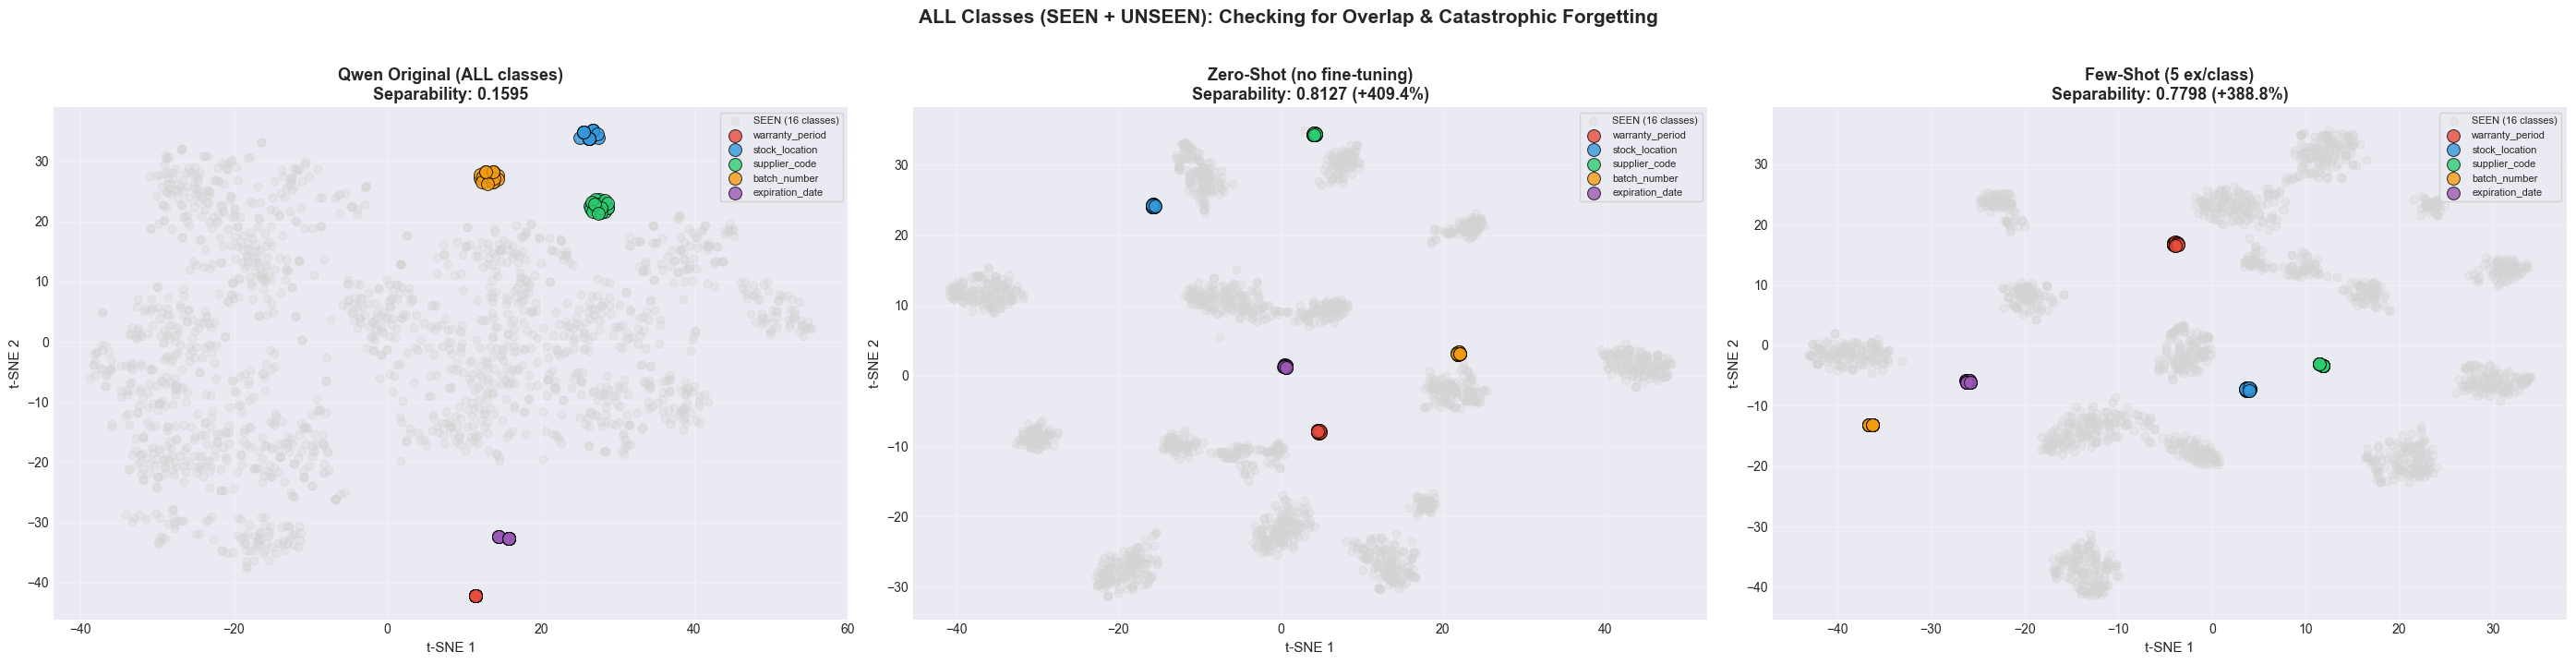

✅ Сохранено: 09_all_classes_seen_unseen.png


In [34]:
# ========================================
# ВИЗУАЛИЗАЦИЯ: ВСЕ КЛАССЫ (SEEN + UNSEEN) - 3 ПАНЕЛИ
# ========================================
print("🔄 t-SNE для ВСЕХ классов (SEEN + UNSEEN)...")

# t-SNE для объединенных данных (Qwen Original)
tsne_combined_orig = TSNE(n_components=2, random_state=42, perplexity=min(50, len(X_combined_orig)-1))
coords_combined_orig = tsne_combined_orig.fit_transform(X_combined_orig)

# t-SNE для Zero-Shot (модель БЕЗ дообучения)
tsne_combined_zs = TSNE(n_components=2, random_state=42, perplexity=min(50, len(X_combined_zeroshot)-1))
coords_combined_zs = tsne_combined_zs.fit_transform(X_combined_zeroshot)

# t-SNE для Few-Shot (модель С дообучением)
tsne_combined_fs = TSNE(n_components=2, random_state=42, perplexity=min(50, len(X_combined_fewshot)-1))
coords_combined_fs = tsne_combined_fs.fit_transform(X_combined_fewshot)

print("✅ t-SNE завершён")

# Цветовая палитра для UNSEEN классов
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# Функция для отрисовки SEEN (серым) + UNSEEN (цветными)
def plot_seen_unseen(ax, coords, y_labels, title, sep_value, sep_change=None):
    # SEEN классы (серым фоном)
    seen_mask = np.isin(y_labels, y_test)
    ax.scatter(coords[seen_mask, 0], coords[seen_mask, 1], 
              c='lightgray', s=40, alpha=0.3, label=f'SEEN ({len(np.unique(y_test))} classes)', zorder=1)
    
    # UNSEEN классы (яркими цветами поверх SEEN)
    for i, class_data in enumerate(unseen_data):
        unseen_mask = y_labels == class_data['class_idx']
        ax.scatter(coords[unseen_mask, 0], coords[unseen_mask, 1], 
                  c=colors[i], s=100, alpha=0.8, 
                  edgecolors='black', linewidth=0.7, 
                  label=class_data['class_name'], zorder=2)
    
    title_str = f"{title}\nSeparability: {sep_value:.4f}"
    if sep_change is not None:
        title_str += f" ({sep_change:+.1f}%)"
    ax.set_title(title_str, fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=11)
    ax.set_ylabel('t-SNE 2', fontsize=11)
    ax.legend(loc='best', fontsize=8, frameon=True, fancybox=True, ncol=1)
    ax.grid(alpha=0.3)

# Трёхпанельная визуализация
fig, axes = plt.subplots(1, 3, figsize=(28, 7))

# 1. Qwen Original (SEEN + UNSEEN)
plot_seen_unseen(axes[0], coords_combined_orig, y_combined, 
                'Qwen Original (ALL classes)', sep_combined_original)

# 2. Zero-Shot (SEEN + UNSEEN, БЕЗ дообучения на UNSEEN)
plot_seen_unseen(axes[1], coords_combined_zs, y_combined, 
                'Zero-Shot (no fine-tuning)', sep_combined_zeroshot, sep_combined_zs_improve)

# 3. Few-Shot (SEEN + UNSEEN, С дообучением на 5 примерах/класс)
plot_seen_unseen(axes[2], coords_combined_fs, y_combined, 
                f'Few-Shot ({FEW_SHOT_SAMPLES} ex/class)', sep_combined_fewshot, sep_combined_fs_improve)

plt.suptitle('ALL Classes (SEEN + UNSEEN): Checking for Overlap & Catastrophic Forgetting', 
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('09_all_classes_seen_unseen.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Сохранено: 09_all_classes_seen_unseen.png")